# Init

In [3]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import os
from importlib import reload  # Python 3.4+
import simulation_classes
reload(simulation_classes)  # Reload the module to ensure recent changes are reflected
from simulation_classes import DriveSignal, CatQubit




## Hamiltonian params

In [4]:
CatQB = CatQubit()

In [5]:
Ix = qt.jmat(7/2, 'x')
Iy = qt.jmat(7/2, 'y')
Iz = qt.jmat(7/2, 'z')
spin_op = CatQB.spin_op
dim = CatQB.dim

In [6]:
Ix**2 + Ix

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1.75       1.32287566 2.29128785 0.         0.         0.
  0.         0.        ]
 [1.32287566 4.75       1.73205081 3.35410197 0.         0.
  0.         0.        ]
 [2.29128785 1.73205081 6.75       1.93649167 3.87298335 0.
  0.         0.        ]
 [0.         3.35410197 1.93649167 7.75       2.         3.87298335
  0.         0.        ]
 [0.         0.         3.87298335 2.         7.75       1.93649167
  3.35410197 0.        ]
 [0.         0.         0.         3.87298335 1.93649167 6.75
  1.73205081 2.29128785]
 [0.         0.         0.         0.         3.35410197 1.73205081
  4.75       1.32287566]
 [0.         0.         0.         0.         0.         2.29128785
  1.32287566 1.75      ]]

In [7]:
nmr_frequencies = np.linspace(7.7e6, 7.7e6 + 7*25e3, 7)  # Frequencies for the NMR drive
frequencies =  np.linspace(7.7e6, 7.7e6 + 7*25e3, 7)
ner2_frequencies = frequencies[0:-1] + frequencies[1:] 
for i in range(6):
    print(str(i)+'->'+str(i+2), ner2_frequencies[i])
    
nmr_ops = []
for i in range(7):
    op = np.zeros((8, 8), dtype=np.complex128)
    op[i, i+1] = Ix[i, i+1]  # Define the operator for the NMR drive
    nmr_ops.append(qt.Qobj(op))  # Append the operator to the list

HNER = (spin_op['Ip']/2)**2 + (spin_op['Im']/2)**2  # Define the Hamiltonian for the NER drive

ner2_ops = []
for i in range(dim-2):
    op = np.zeros((dim, dim), dtype=np.complex128)
    op[i, i+2]  = HNER[i, i+2]
    ner2_ops.append(qt.Qobj(op))

drive_dict = {
    'ner2': {
        'frequencies': ner2_frequencies,  # Frequencies for the drive
        'ops': ner2_ops,  # Operators for the drive
        'order': 2,  # order of the off-diagonals of the drive (Needed for RF)
    },
    'nmr': {
        'frequencies': nmr_frequencies,  # Frequencies for the drive
        'ops': nmr_ops,  # Operators for the drive
        'order': 1,  # order of the off-diagonals of the drive (Needed for RF)
    },
}

0->2 15429166.666666668
1->3 15487500.0
2->4 15545833.333333332
3->5 15604166.666666668
4->6 15662500.0
5->7 15720833.333333332


## Pulse params

In [739]:
def sin_sq_env(t, T, Trise):
    amp_rescale = 1/(1 - Trise)
    return  amp_rescale*((np.heaviside(t, 1) - np.heaviside(t - Trise*T, 1)) * np.sin(np.pi/2*t/(Trise*T))**2 + \
        (np.heaviside(t - Trise*T, 1) - np.heaviside(t - (1-Trise)*T, 1)) + \
        (np.heaviside(t - (1-Trise)*T, 1) - np.heaviside(t - T, 1)) * np.sin(np.pi/2*(t-(T-Trise*T))/(Trise*T) + np.pi/2)**2)

def sin_sq_rise(t, T):
    return   np.sin(np.pi/2*t/(T))**2 

def sin_sq_fall(t, T):
    return   np.sin(np.pi/2*t/(T)+np.pi/2)**2 


pulse_shape_dict = {
    # all functions shouls have a t and T dependence. amplitudes should be handled outside.
    'square': {
        'function': lambda t, T: np.ones(len(t)),
        'args': {},
    },
    'sin_sq': {
        'function': sin_sq_env,
        'args': {
            'Trise': 0.3
        },
    },
    'sin_sq_rise': {
        'function': sin_sq_rise,
        'args': {},
    },
    'sin_sq_fall': {
        'function': sin_sq_fall,
        'args': {},
    }
}

# Encoding

In [9]:
import matplotlib as mpl
cmap = mpl.colors.LinearSegmentedColormap.from_list('my_gradient', (
    # Edit this gradient at https://eltos.github.io/gradient/#0:7F7F7F-76.5:87AADA-88.7:619AE8-97.2:468BE9-100:006BFF
    (0.000, (0.498, 0.498, 0.498)),
    (0.765, (0.529, 0.667, 0.855)),
    (0.887, (0.380, 0.604, 0.910)),
    (0.972, (0.275, 0.545, 0.914)),
    (1.000, (0.000, 0.420, 1.000))))


## regular NMR encoding

In [10]:
target_U = (-1j * np.pi/2 *Iy).expm()  # Target unitary operation for the simulation
target_state = target_U * qt.basis(8, 0)

In [159]:
target_state

Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.08838835]
 [0.23385359]
 [0.40504629]
 [0.52291252]
 [0.52291252]
 [0.40504629]
 [0.23385359]
 [0.08838835]]

In [160]:
amp_array = np.linspace(0.1, 10, 10)
Trise = 0.0001
results = []
Tenc = []
time_arrays = []
for amp in amp_array:
    base_amp = 1166.6666/7*amp# pi time 3 ms
    base_T = 1.5e-3/amp
    cross_coupling_cutoff = 7
    Tenc.append(base_T)
    pulses = DriveSignal(drive_dict=drive_dict, pulse_shapes=pulse_shape_dict, dt=1e-6)
    pulses.init_drive_signal_list()
    pulses.frame_rotation('nmr', -np.pi/2)
    pulses.pulse_shapes['sin_sq']['args']['Trise'] = Trise
    pulses.global_pulse('nmr', T=base_T*1.2, pulse_shape='square', amp=base_amp )
    pulses.finish_pulse_sequence()
    Hdrive, time_array = pulses.get_drive_hamiltonian(nmr_frequencies, cross_coupling_cutoff=cross_coupling_cutoff)
    time_arrays.append(time_array)
    result = qt.mesolve(Hdrive, qt.basis(dim, 0), time_array, e_ops=[Ix, Iy, Iz, qt.ket2dm(target_state)])
    results.append(result)

TypeError: DriveSignal.get_drive_hamiltonian() got an unexpected keyword argument 'cross_coupling_cutoff'

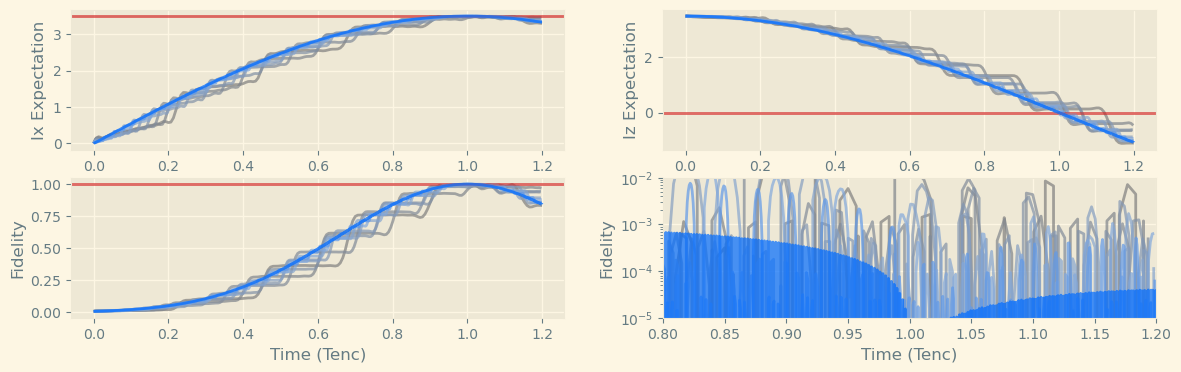

In [ ]:
colors = cmap(np.linspace(0, 1, len(results)))
fig, axs = plt.subplots(2, 2, figsize=(14, 4))
for ir, r in enumerate(results):
    result = results[-(ir+1)]
    axs[0, 0].plot(time_arrays[-(ir+1)]/Tenc[-(ir+1)],result.expect[0], color=colors[ir], alpha=0.7)
    axs[0, 0].axhline(3.5, color='tab:red', alpha=0.1)
    axs[0, 0].set_xlabel('Time (Tenc)')
    axs[0, 0].set_ylabel('Ix Expectation')
    axs[0, 1].plot(time_arrays[-(ir+1)]/Tenc[-(ir+1)],result.expect[2], color=colors[ir], alpha=0.7)
    axs[0, 1].set_ylabel('Iz Expectation')
    axs[0, 1].set_xlabel('Time (Tenc)')
    axs[0, 1].axhline(0, color='tab:red', alpha=0.1)

    axs[1, 0].plot(time_arrays[-(ir+1)]/Tenc[-(ir+1)],result.expect[3], color=colors[ir], alpha=0.7)
    axs[1, 0].set_ylabel('Fidelity')
    axs[1, 0].set_xlabel('Time (Tenc)')
    axs[1, 0].axhline(1, color='tab:red', alpha=0.1)

    diff_time_array = (time_arrays[-(ir+1)][:-1] + time_arrays[-(ir+1)][1:])/2
    axs[1, 1].semilogy(diff_time_array/Tenc[-(ir+1)]  , np.diff(result.expect[3]), color=colors[ir], alpha=0.7)
    axs[1, 1].set_ylabel('Fidelity')
    axs[1, 1].set_xlabel('Time (Tenc)')
    axs[1, 1].set_xlim(0.8, 1.2)
    axs[1, 1].set_ylim(1e-5, 1e-2)


In [ ]:
import xarray as xr
import pandas as pd

# EXP: Encode experiment 1

In [ ]:
def set_up_data_arrays(sweep_params: dict[str, np.ndarray],
                       observables: dict[str, qt.Qobj],
                       store_time_trace: list[str] = [],
                       time_samples: int = 100,
                       ):
    '''
    Set up data arrays for the encoding experiment.
    If you want states to be stored add {'state': qt.identity(dimension)} as observable.
    identity is arbitrary but will help get the Hilbertspace size
    '''
    coords = sweep_params.copy()
    if len(store_time_trace) > 0:
        coords_t = coords.copy()
        coords_t['t_idx'] = np.arange(time_samples)
    if 'state' in observables.keys():
        if 'state' in store_time_trace:
            coords_dm = coords_t.copy()
        else:
            coords_dm = coords.copy()
        Hdim = observables['state'].full().shape[0]
        coords_dm['dm_i'] = np.arange(Hdim)
        coords_dm['dm_j'] = np.arange(Hdim)

    observable_ops = []
    observable_names = []
    sweep_param_names = []
    data_shape = []
    for key, value in sweep_params.items():
        data_shape.append(len(value))
        sweep_param_names.append(key)

    results = xr.Dataset()
    for key, value in observables.items():
        observable_ops.append(value)
        observable_names.append(key)
        if key == 'state':
            if 'state' in store_time_trace:
                results[key] = xr.DataArray(np.zeros(data_shape +  [time_samples, Hdim, Hdim], dtype=np.complex128),
                                            coords=coords_dm)
            else:
                results[key] = xr.DataArray(np.zeros(data_shape +  [Hdim, Hdim], dtype=np.complex128),
                                      coords=coords_dm)
        else:   
            if key in store_time_trace:
                results[key] = xr.DataArray(np.zeros(data_shape + [time_samples]),
                                            coords=coords_t)
            else:
                results[key] = xr.DataArray(np.zeros(data_shape),
                                            coords=coords)

    return results, observable_names, observable_ops

def save_experiment(results, experiment_name, folder):
    new_name = False
    r = 0
    while new_name == False:
        filename = experiment_name + f'_{r}.nc' 
        if not os.path.exists(folder + filename):
            new_name = True
        else:
            r += 1

    if 'state' in results:
        results['state_Re'] = results.state.real
        results['state_Im'] = results.state.imag
        results.drop_vars('state').to_netcdf(folder + filename)
    else:
        results.to_netcdf(folder + filename)
    print(f"Results saved to {folder + filename}")

def run_encode_experiment(Tenc_array, amp_error_array,
                          observables: dict[str, qt.Qobj],
                          pulse_shape: str='square',
                          init_state = qt.basis(8, 0),
                          Trise: float = 0.2,
                          cross_coupling_cutoff_frequency= None,
                          store_time_trace: list[str] = [],
                          dt = 5e-7,
                          nr_time_samples: int = 100):

    results, observable_names, observable_ops = set_up_data_arrays(
        sweep_params={'Tenc': Tenc_array, 'amp_error': amp_error_array},
        observables=observables,
        store_time_trace=store_time_trace,
        time_samples=nr_time_samples
    )
    results.attrs['pulse_shape'] = pulse_shape
    results.attrs['Trise'] = Trise
    # results.attrs['init_state'] = init_state.full()
    results.attrs['cross_coupling_cutoff'] = cross_coupling_cutoff
    results.attrs['dt'] = dt

    for it, Tenc in enumerate(Tenc_array):
        for ia, amp_error in enumerate(amp_error_array):

            amp = 0.25/Tenc 
            pulses = DriveSignal(drive_dict=drive_dict, pulse_shapes=pulse_shape_dict, dt=dt)
            pulses.pulse_shapes['sin_sq']['args']['Trise'] = Trise
            pulses.init_drive_signal_list()
            pulses.frame_rotation('nmr', -np.pi/2)
            pulses.global_pulse('nmr', T=Tenc, pulse_shape=pulse_shape, amp=amp*amp_error )
            pulses.finish_pulse_sequence()
            Hdrive, time_array = pulses.get_drive_hamiltonian(nmr_frequencies, cross_coupling_cutoff_frequency=cross_coupling_cutoff_frequency)
            result = qt.mesolve(Hdrive, init_state, time_array)

            # analysis
            final_state = result.states[-1]
            time_samples = np.linspace(0, len(time_array)-1, nr_time_samples, dtype=int) # resampling time evolution because they are not all the same length
            for iob, op in enumerate(observable_ops):
                if observable_names[iob] in store_time_trace:
                    exp_time_samples = []
                    for t in time_samples:
                        if observable_names[iob] == 'state':
                            state = result.states[t]
                            if state.type == 'ket':
                                state = qt.ket2dm(state)
                            exp_time_samples.append(state.full())
                        else:
                            exp_time_samples.append(qt.expect(op, result.states[t]))
                    results[observable_names[iob]][it, ia,] = exp_time_samples
                else:
                    if observable_names[iob] == 'state':
                        state = result.states[-1]
                        if state.type == 'ket':
                            state = qt.ket2dm(state)
                        results[observable_names[iob]][it, ia] = state.full()
                    else:
                        results[observable_names[iob]][it, ia] = qt.expect(op, final_state)
    return results

def plot_encode_experiment(results):
    import matplotlib.colors as mcolor
    if isinstance(results, str):
        results = xr.load_dataset(results)
    fidelity = results['Fidelity']
    infidelity = (1-results['Fidelity'])
    infidelity = infidelity.rename('Infidelity')

    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    plt.sca(axs[0])
    # plt.title(f"Final Result: infidelity")
    fidelity.plot.pcolormesh(vmin=0.9,)
    # plt.colorbar(label=res.attrs['operator'])
    plt.xlabel('Amplitude Error')
    plt.ylabel('Encoding Time')
    
    plt.sca(axs[1])
    # plt.title(f"Final Result: infidelity")
    infidelity.plot.pcolormesh(norm=mcolors.LogNorm(vmin=1e-5, vmax=1e-1))
    # plt.colorbar(label='Infidelity')
    plt.xlabel('Amplitude Error')
    plt.ylabel('Encoding Time')
    plt.show()


In [ ]:
target_U = (-1j * np.pi/2 *Iy).expm()  # Target unitary operation for the simulation
target_state = target_U * qt.basis(8, 0)


In [ ]:
folder = './data/encode/'

In [ ]:
results,  observable_names, observable_ops= set_up_data_arrays(
    sweep_params={'Tenc': Tenc_array, 'amp_error': amp_error_array},
    observables=observables,
    store_time_trace=['Iz', 'Ix'],
    time_samples=101
)

state


In [ ]:
# init


Tenc_array = np.linspace(100e-6, 3e-3, 6)
amp_error_array = np.linspace(0.95, 1.05, 6)

observables = {
    'Fidelity': qt.ket2dm(target_state),
    'Ix': Ix,
    'Iz': Iz,
    'state': qt.identity(8)  # Identity operator to get the Hilbert space size
}

# run
experiment_name = f"test"
results= run_encode_experiment(Tenc_array, amp_error_array,
                            observables=observables,
                            pulse_shape='sin_sq',
                            Trise=Trise,
                            cross_coupling_cutoff_frequency=7,
                            store_time_trace=['Iz', 'Ix', 'state']
)
save_experiment(results, experiment_name, folder)

Results saved to ./data/encode/test_7.nc


In [ ]:
# init


Tenc_array = np.linspace(100e-6, 3e-3, 31)
amp_error_array = np.linspace(0.95, 1.05, 61)



# run
Trise_array = [ 0.1,]
target_init_states = {'+X': (qt.basis(8, 0)+qt.basis(8, 7))/np.sqrt(2),
                      '-X': (qt.basis(8, 0)-qt.basis(8, 7))/np.sqrt(2),
                      '+Y': (qt.basis(8, 0)+1j*qt.basis(8, 7))/np.sqrt(2),
                      '-Y': (qt.basis(8, 0)-1j*qt.basis(8, 7))/np.sqrt(2),
                      '+Z': qt.basis(8, 0),
                      '-Z': qt.basis(8, 7)}

for targ in ['+X', '-X', '+Y', '-Y', '+Z', '-Z']:
    target_state = target_U * target_init_states[targ]
    observables = {
    'Fidelity': qt.ket2dm(target_state),
    'Ix': Ix,
    'Iz': Iz,
    'state': qt.identity(8)  # Identity operator to get the Hilbert space size
}
    for Trise in Trise_array:
        experiment_name = f"encode_{targ}_vs_time_vs_amp_error_Trise={Trise}"
        results= run_encode_experiment(Tenc_array, amp_error_array,
                                    observables=observables,
                                    pulse_shape='sin_sq',
                                    Trise=Trise,
                                    store_time_trace=['Iz', 'Ix'],
                                    init_state=target_init_states[targ]
        )
        save_experiment(results, experiment_name, folder)
        

Results saved to ./data/encode/encode_+X_vs_time_vs_amp_error_Trise=0.1_0.nc
Results saved to ./data/encode/encode_-X_vs_time_vs_amp_error_Trise=0.1_0.nc
Results saved to ./data/encode/encode_+Y_vs_time_vs_amp_error_Trise=0.1_0.nc
Results saved to ./data/encode/encode_-Y_vs_time_vs_amp_error_Trise=0.1_0.nc
Results saved to ./data/encode/encode_+Z_vs_time_vs_amp_error_Trise=0.1_0.nc
Results saved to ./data/encode/encode_-Z_vs_time_vs_amp_error_Trise=0.1_0.nc


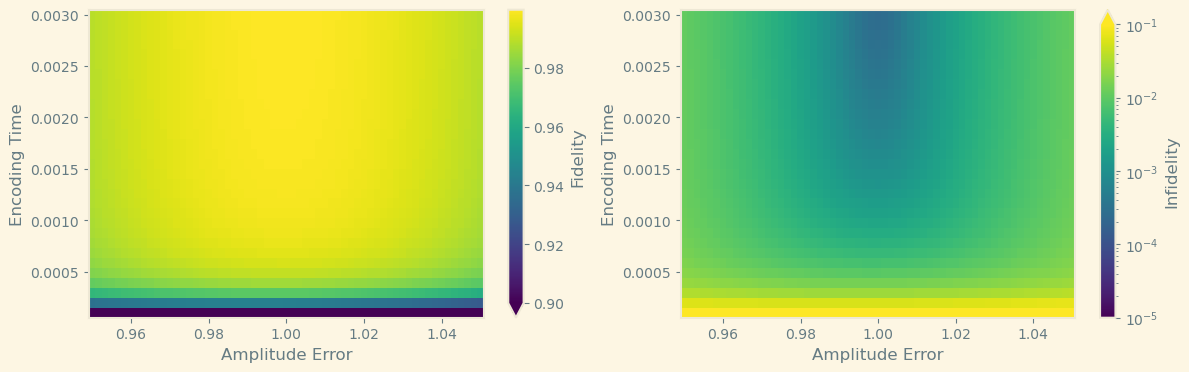

In [ ]:
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.5_0.nc')


In [ ]:
def fidelity_after_Iz_phase(phi, state, target_state):
    if state.type == 'ket':
        state = qt.ket2dm(state)
    Urot = (-1j*phi*qt.jmat(7/2, 'z')).expm()
    state = Urot * state * Urot.dag()
    return qt.fidelity(state, target_state)

from scipy.optimize import minimize_scalar

def optimize_fidelity(final_state, target_state):
    result = minimize_scalar(lambda phi: 1-fidelity_after_Iz_phase(phi, final_state, target_state), bounds=(0, 2*np.pi), method='bounded')
    return result


In [ ]:
final_state = qt.Qobj(results.state.isel(amp_error=i, Tenc=j))

fidelity_after_Iz_phase(np.pi/200, final_state, target_state)

np.float64(0.9939413971791232)

In [ ]:
optimize_fidelity(final_state, target_state)

 message: Solution found.
 success: True
  status: 0
     fun: 0.0053857774754911825
       x: 6.2711282421441945
     nit: 20
    nfev: 20

In [ ]:
opt_infidelity


<xarray.DataArray (amp_error: 61, Tenc: 31)> Size: 15kB
array([[0.01319661, 0.00589156, 0.00570576, ..., 0.00538795, 0.0053877 ,
        0.00538756],
       [0.01294883, 0.00554868, 0.00535405, ..., 0.00503577, 0.00503554,
        0.00503538],
       [0.01271273, 0.00521769, 0.00501413, ..., 0.00469543, 0.00469519,
        0.00469505],
       ...,
       [0.01814769, 0.00554272, 0.00493033, ..., 0.00469369, 0.00469358,
        0.00469337],
       [0.01857371, 0.00588447, 0.00526717, ..., 0.00503398, 0.00503386,
        0.00503367],
       [0.01901099, 0.00623784, 0.00561569, ..., 0.00538608, 0.00538596,
        0.00538578]], shape=(61, 31))
Coordinates:
  * amp_error  (amp_error) float64 488B 0.95 0.9517 0.9533 ... 1.047 1.048 1.05
  * Tenc       (Tenc) float64 248B 0.0001 0.0001967 0.0002933 ... 0.002903 0.003

In [ ]:
# filename = r'./data/encode/encode_vs_time_vs_amp_error_Trise=0.5_1.nc'
# filename = r'./data/encode/encode_vs_time_vs_amp_error_Trise=0.3_1.nc'
# filename = r'./data/encode/encode_vs_time_vs_amp_error_Trise=0.1_1.nc'
# filename = r'./data/encode/encode_vs_time_vs_amp_error_Trise=0.0001_1.nc'
filename= r'./data/encode/encode_+X_vs_time_vs_amp_error_Trise=0.1_0.nc'
# filename= r'./data/encode/encode_-X_vs_time_vs_amp_error_Trise=0.1_0.nc'
# filename= r'./data/encode/encode_+Y_vs_time_vs_amp_error_Trise=0.1_0.nc'

# filename= r'./data/encode/encode_-Y_vs_time_vs_amp_error_Trise=0.1_0.nc'
target_state = target_U * target_init_states['+X']
results = xr.load_dataset(filename)
results['state'] = results.state_Re + 1j*results.state_Im
opt_infidelity = np.zeros((len(results.amp_error), len(results.Tenc)))
snap_for_opt_fid = np.zeros((len(results.amp_error), len(results.Tenc)))
for i in range(len(results.amp_error)):
    for j in range(len(results.Tenc)):
        final_state = qt.Qobj(results.state.isel(amp_error=i, Tenc=j))
        opt_phase_infidelity = optimize_fidelity(final_state, target_state)
        opt_infidelity[i, j] = opt_phase_infidelity.fun
        snap_phase = opt_phase_infidelity.x
        if snap_phase > np.pi:
            snap_phase -= 2*np.pi
        snap_for_opt_fid[i, j] = snap_phase
        

snap_for_opt_fid = xr.DataArray(snap_for_opt_fid, coords=[results.amp_error, results.Tenc], dims=['amp_error', 'Tenc'])
opt_infidelity = xr.DataArray(opt_infidelity, coords=[results.amp_error, results.Tenc], dims=['amp_error', 'Tenc'])

infidelity = (1-results['Fidelity'])
infidelity = infidelity.rename('Infidelity')



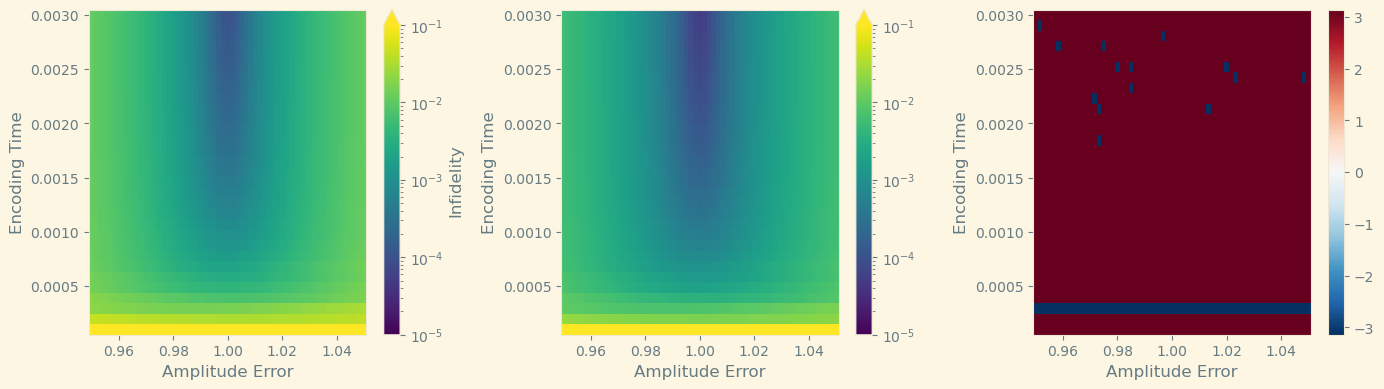

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))
plt.sca(axs[0])
# plt.title(f"Final Result: infidelity")
infidelity.plot.pcolormesh(norm=mcolors.LogNorm(vmin=1e-5, vmax=1e-1))
# plt.colorbar(label=res.attrs['operator'])
plt.xlabel('Amplitude Error')
plt.ylabel('Encoding Time')

plt.sca(axs[1])
# plt.title(f"Final Result: infidelity")
opt_infidelity.plot.pcolormesh(x='amp_error', y='Tenc', norm=mcolors.LogNorm(vmin=1e-5, vmax=1e-1))
# plt.colorbar(label='Infidelity')
plt.xlabel('Amplitude Error')
plt.ylabel('Encoding Time')

plt.sca(axs[2])
# plt.title(f"Final Result: infidelity")
snap_for_opt_fid.plot.pcolormesh(x='amp_error', y='Tenc',)
# plt.colorbar(label='Infidelity')
plt.xlabel('Amplitude Error')
plt.ylabel('Encoding Time')

fig.tight_layout()

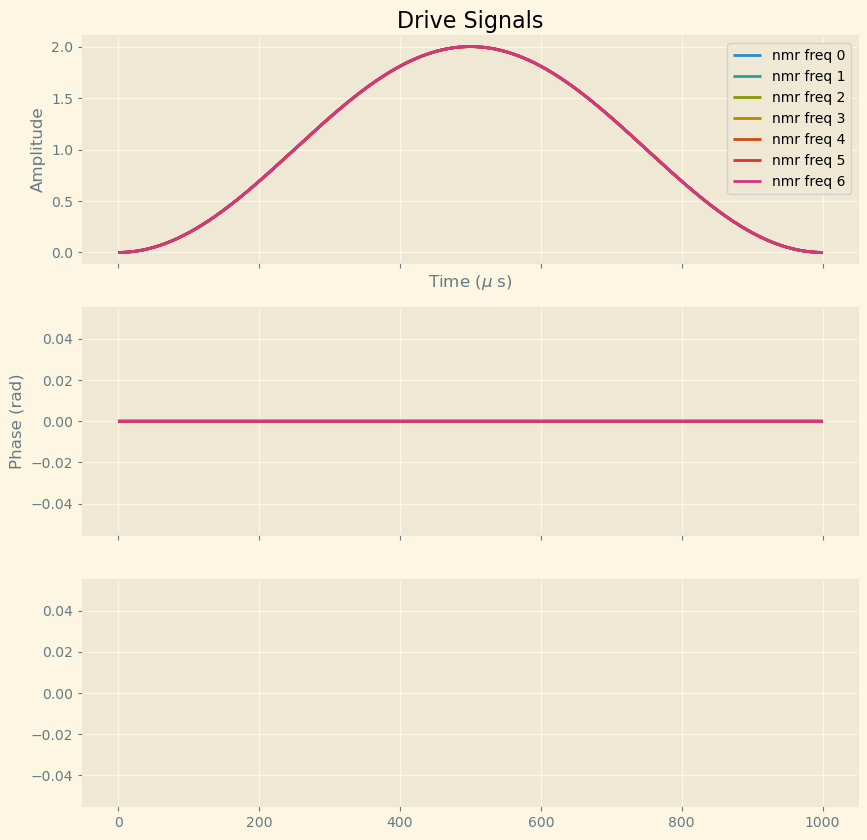

In [ ]:
ps = DriveSignal(drive_dict=drive_dict, pulse_shapes=pulse_shape_dict, dt=1e-7)
ps.pulse_shapes['sin_sq']['args']['Trise'] = 0.5
ps.init_drive_signal_list()
ps.global_pulse('nmr', T=0.001, pulse_shape='sin_sq', amp=1)
ps.plot_signal('nmr')

In [ ]:
filename = './data/encode/encode_vs_time_vs_amp_error_Trise=0.001_0'
os.path.exists(filename)

False

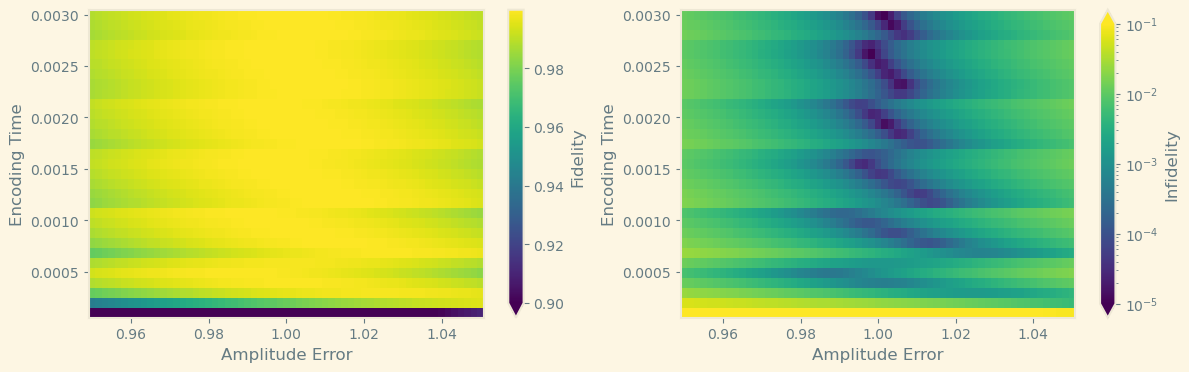

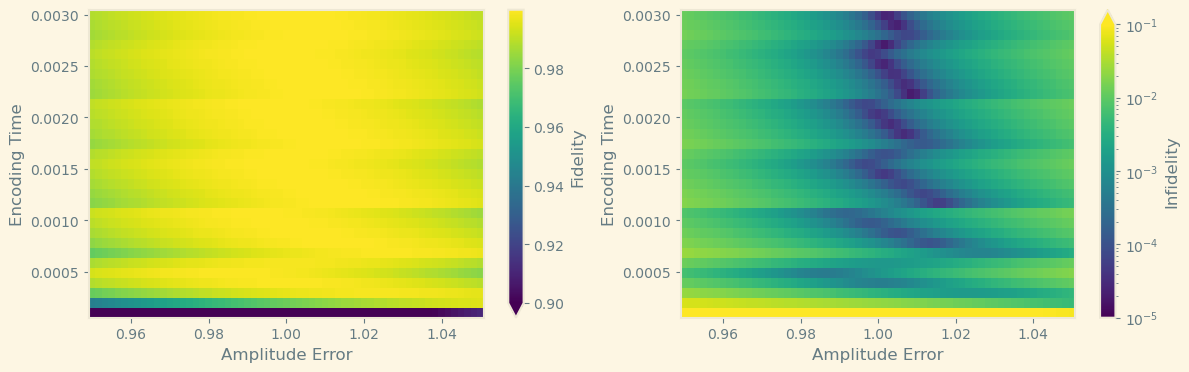

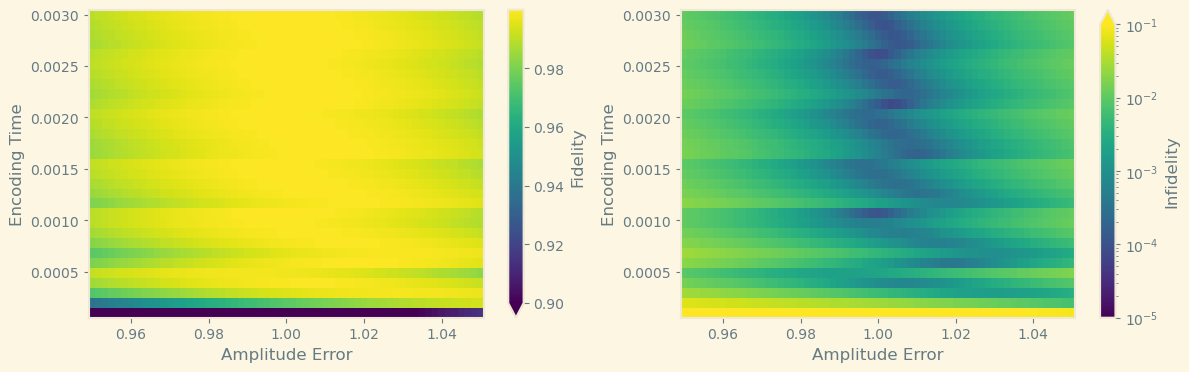

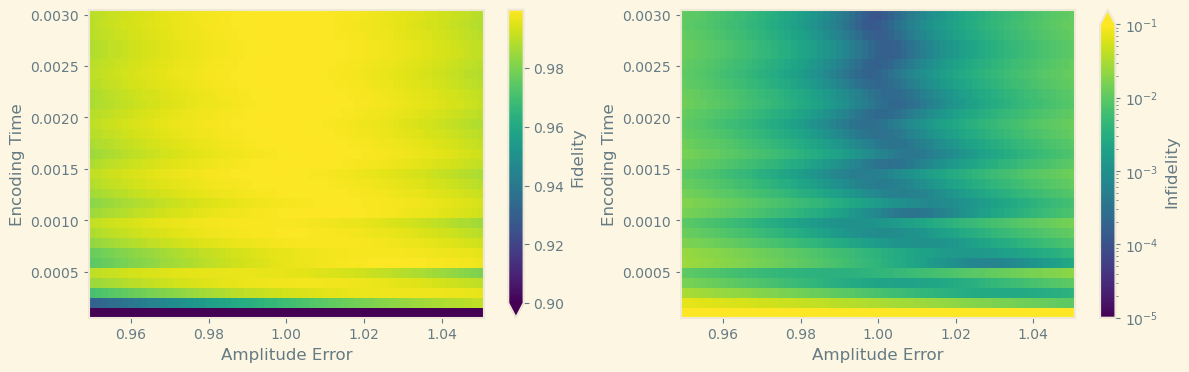

In [ ]:
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.0001_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.001_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.005_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.01_0.nc')

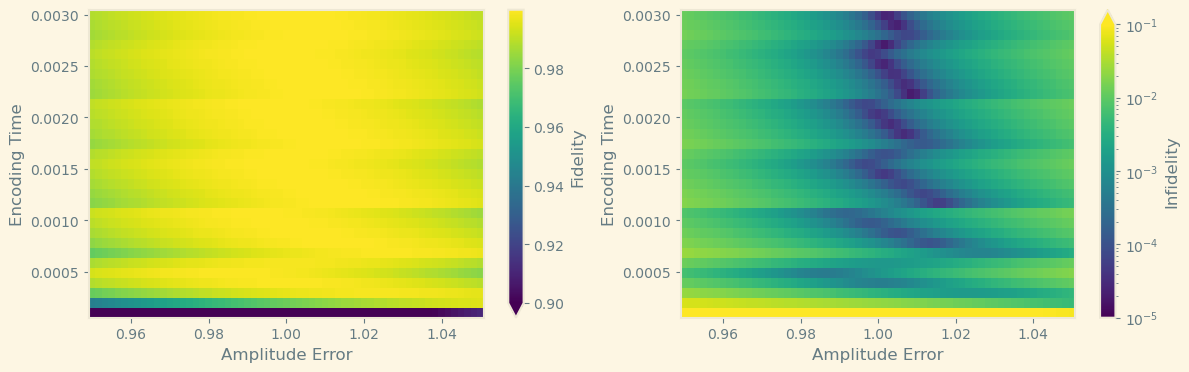

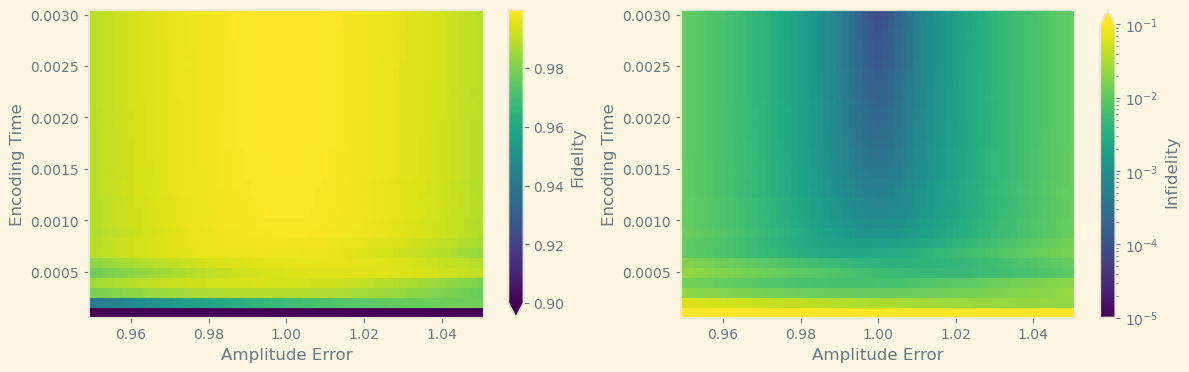

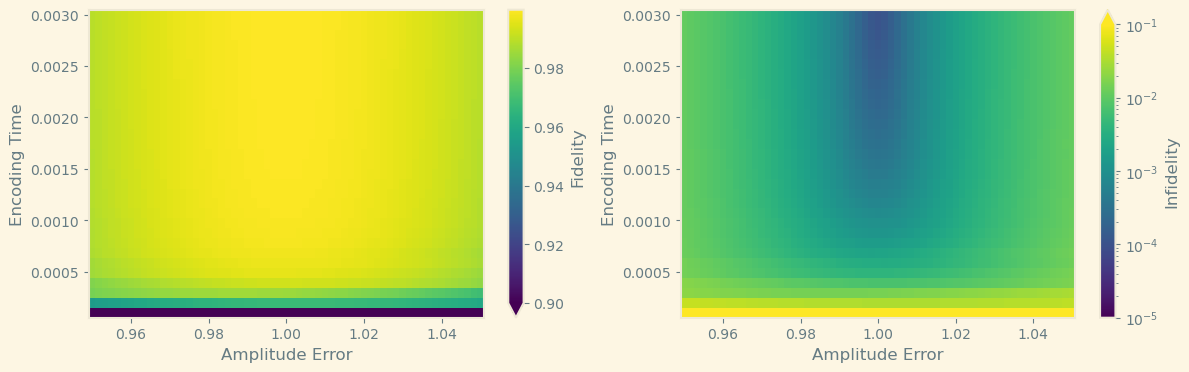

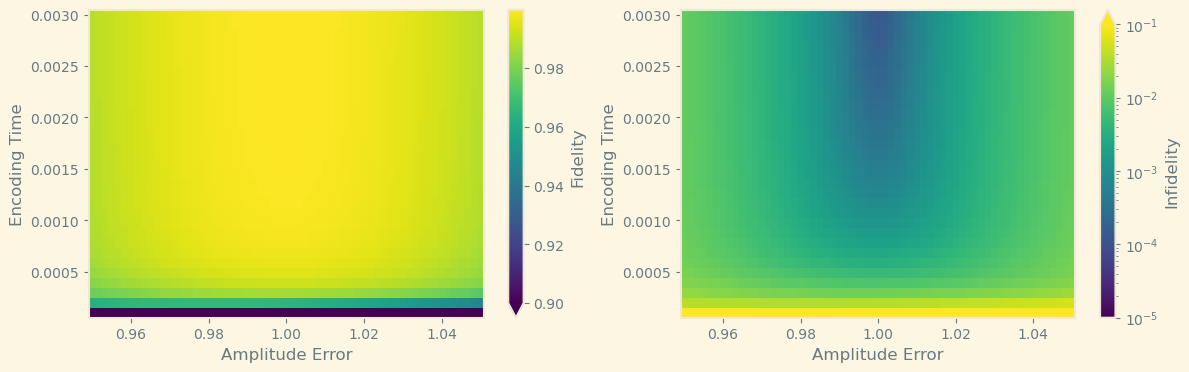

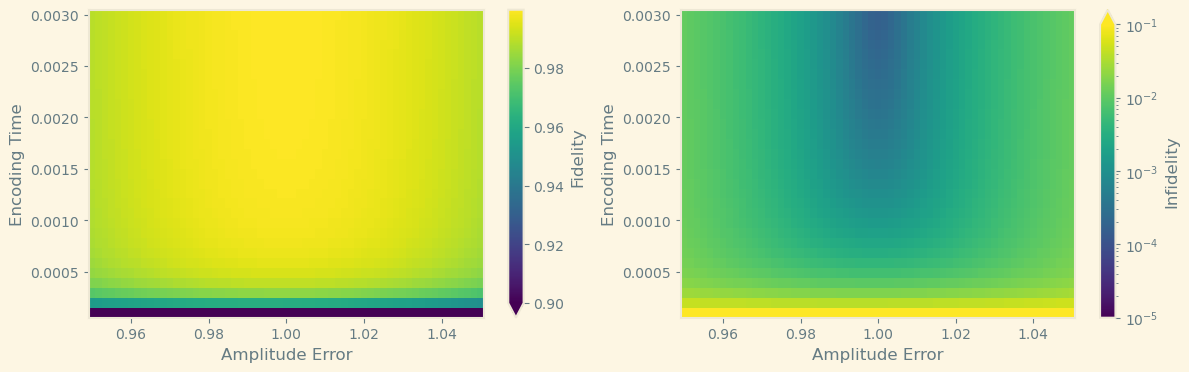

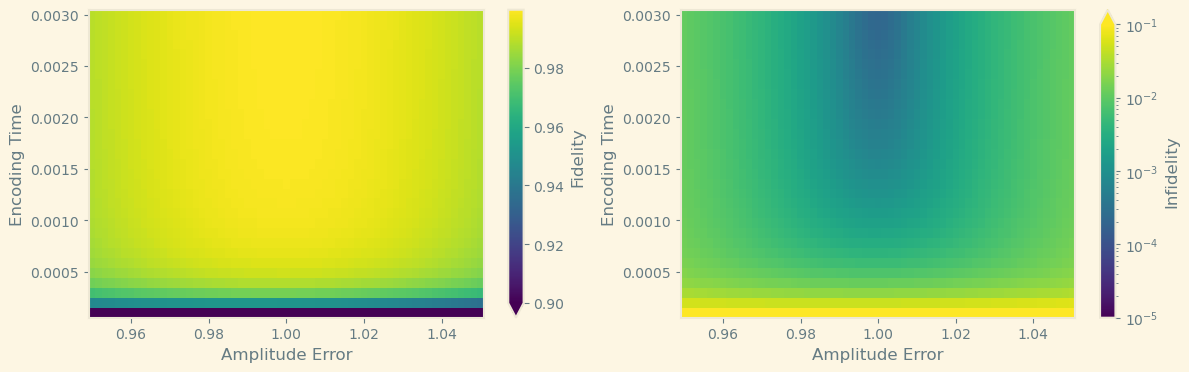

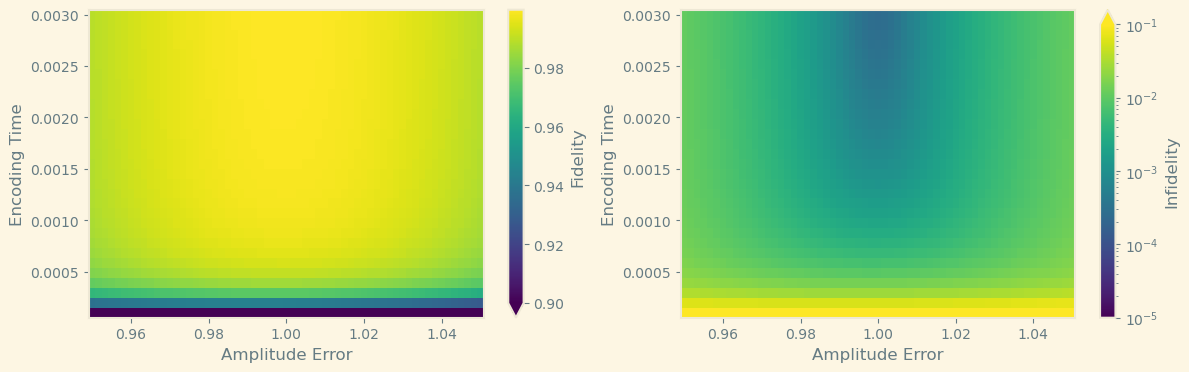

In [ ]:
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.001_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.05_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.1_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.2_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.3_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.4_0.nc')
plot_encode_experiment('./data/encode/encode_vs_time_vs_amp_error_Trise=0.5_0.nc')

In [ ]:
1/0.003

333.3333333333333

# EXP: Stark shift experiment 1 Extra drives

(0.9, 1.2)

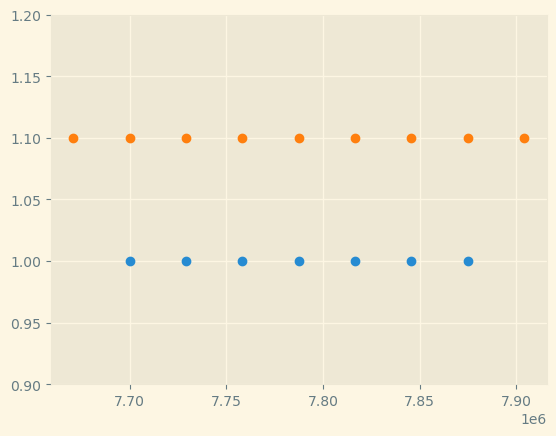

In [ ]:
plt.scatter(nmr_frequencies, np.ones_like(nmr_frequencies))
splitting = np.mean(np.diff(nmr_frequencies))

Nextend = 1
ext_nmr_frequencies = np.array([*np.arange(nmr_frequencies[0] - splitting * Nextend, nmr_frequencies[0]-1, splitting), *nmr_frequencies, *np.arange(nmr_frequencies[-1] + splitting, nmr_frequencies[-1] + splitting * (Nextend+1), splitting)])
plt.scatter(ext_nmr_frequencies, np.ones_like(ext_nmr_frequencies) * 1.1, color='tab:orange', label='Extended NMR Frequencies')
plt.ylim(0.9, 1.2)


In [ ]:
def run_nmr_extend_experiment(Next_array, Tenc_array,
                          nmr_frequencies: np.ndarray,
                          observables: dict[str, qt.Qobj],
                          pulse_shape: str='square',
                          Trise: float = 0.2,
                          store_time_trace: list[str] = [],
                          dt = 5e-7,
                          nr_time_samples: int = 100):

    results, observable_names, observable_ops = set_up_data_arrays(
        sweep_params={'Next': Next_array, 'Tenc': Tenc_array},
        observables=observables,
        store_time_trace=store_time_trace,
        time_samples=nr_time_samples
    )
    results.attrs['pulse_shape'] = pulse_shape
    results.attrs['nmr_frequencies'] = nmr_frequencies
    results.attrs['Trise'] = Trise
    results.attrs['dt'] = dt

    for inex, Next in enumerate(Next_array):
        splitting = np.mean(np.diff(nmr_frequencies))
        ext_nmr_frequencies = np.array([*np.arange(nmr_frequencies[0] - splitting * Next, nmr_frequencies[0]-1, splitting), *nmr_frequencies, *np.arange(nmr_frequencies[-1] + splitting, nmr_frequencies[-1] + splitting * (Next+1), splitting)])
        special_drive_dict = {
                'nmr': {
                    'frequencies': ext_nmr_frequencies,  # Frequencies for the drive
                    'operator': qt.jmat(7/2, 'x'),  # Operators for the drive
                    'order': 1,  # order of the off-diagonals of the drive (Needed for RF)
            },
        }
        for it, Tenc in enumerate(Tenc_array):

            amp = 0.25/Tenc
            pulses = DriveSignal(drive_dict=special_drive_dict, pulse_shapes=pulse_shape_dict, dt=dt)
            pulses.pulse_shapes['sin_sq']['args']['Trise'] = Trise
            pulses.init_drive_signal_list()
            pulses.frame_rotation('nmr', -np.pi/2)
            pulses.global_pulse('nmr', T=Tenc, pulse_shape=pulse_shape, amp=amp)
            pulses.finish_pulse_sequence()
            Hdrive, time_array = pulses.get_drive_hamiltonian(nmr_frequencies, cross_coupling_cutoff_frequency=None)
            result = qt.mesolve(Hdrive, qt.basis(dim, 0), time_array)

            # analysis
            final_state = result.states[-1]
            time_samples = np.linspace(0, len(time_array)-1, nr_time_samples, dtype=int) # resampling time evolution because they are not all the same length

            for iob, op in enumerate(observable_ops):
                if observable_names[iob] in store_time_trace:
                    exp_time_samples = []
                    for t in time_samples:
                        if observable_names[iob] == 'state':
                            state = result.states[t]
                            if state.type == 'ket':
                                state = qt.ket2dm(state)
                            exp_time_samples.append(state.full())
                        else:
                            exp_time_samples.append(qt.expect(op, result.states[t]))
                    results[observable_names[iob]][inex, it] = exp_time_samples
                else:
                    if observable_names[iob] == 'state':
                        state = result.states[-1]
                        if state.type == 'ket':
                            state = qt.ket2dm(state)
                        results[observable_names[iob]][inex, it] = state.full()
                    else:
                        results[observable_names[iob]][inex, it] = qt.expect(op, final_state)
    return results




In [ ]:
target_U = (-1j * np.pi/2 *Iy).expm()  # Target unitary operation for the simulation
target_state = target_U * qt.basis(8, 0)
folder = './data/encode/'

In [ ]:
Tenc_array

array([0.0001 , 0.00068, 0.00126, 0.00184, 0.00242, 0.003  ])

In [ ]:
# init

N = 9
Tenc_array = np.linspace(5e-4, 3e-3, N)
Next_array = np.arange(0, N)

observables = {
    'Fidelity': qt.ket2dm(target_state),
    'Ix': Ix,
    'Iz': Iz,
    'state': qt.identity(8)  # Identity operator to get the Hilbert space size
}

# run
experiment_name = f"Extra_drives"
results= run_nmr_extend_experiment(Next_array, Tenc_array,
                                   nmr_frequencies=nmr_frequencies,
                            observables=observables,
                            pulse_shape='sin_sq',
                            Trise=Trise,
                            store_time_trace=['Iz', 'Ix', 'state']
)
save_experiment(results, experiment_name, folder)

Results saved to ./data/encode/Extra_drives_4.nc


In [ ]:
def plot_nmr_extend_experiment(results):
    import matplotlib.colors as mcolor
    if isinstance(results, str):
        results = xr.load_dataset(results)
        results['state'] = results.state_Re + 1j*results.state_Im

    fidelity = results['Fidelity']
    infidelity = (1-results['Fidelity'])
    infidelity = infidelity.rename('Infidelity')

    final_state = results.state.isel(t_idx=-1)
    phases = np.zeros((len(results.Next), len(results.Tenc), 7), dtype=np.complex128)
    for i in range(len(results.Next)):
        for j in range(len(results.Tenc)):
            phases[i, j] = np.angle(np.diag(final_state[i, j], 1))
    fig, axs = plt.subplots(2, len(results.Next), figsize=(16, 3), sharey=True)
    for i in range(len(results.Next)):
        plt.sca(axs[0, i])
        plt.title(f"Extra Drives: {results.Next[i].values} drives", fontdict={'fontsize': 8})
        plt.plot(np.arange(7), phases[i].T)
        # plt.legend(results.Tenc.to_numpy()*1e3)
        plt.xlabel('Transition')
    axs[0, 0].set_ylabel('phase')

    tencs = results.Tenc.to_numpy()
    for i in range(len(results.Tenc)):
        plt.sca(axs[1, i])
        plt.title(f"Tenc: {np.round(tencs[i]*1e3, 2)} ms", fontdict={'fontsize': 8})
        plt.sca(axs[1, i])
        plt.plot(np.arange(7), phases[:, i].T)
        # plt.legend(results.Next.to_numpy())
        plt.xlabel('Transition')
    axs[1, 0].set_ylabel('phase')
    fig.tight_layout()
    fig2 ,axs2 = plt.subplots(1, 2, figsize = (8,3))
    # plt.title(f"Final Result: infidelity")
    infidelity.plot.pcolormesh(ax=axs2[0], norm=mcolors.LogNorm(vmin=1e-5, vmax=1e-1))
    
    splitting = np.mean(np.diff(nmr_frequencies))
    for inex, nex in enumerate(results.Next.to_numpy()):
        ext_nmr_frequencies = np.array([*np.arange(nmr_frequencies[0] - splitting * nex, nmr_frequencies[0]-1, splitting), *nmr_frequencies, *np.arange(nmr_frequencies[-1] + splitting, nmr_frequencies[-1] + splitting * (nex+1), splitting)])
        axs2[1].scatter(ext_nmr_frequencies, np.ones_like(ext_nmr_frequencies) * (inex))
    axs2[1].set_xlabel('nmr freq (Hz)')
    axs2[1].set_ylabel('Nr extra drives')
    fig2.tight_layout()
    plt.show()

c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


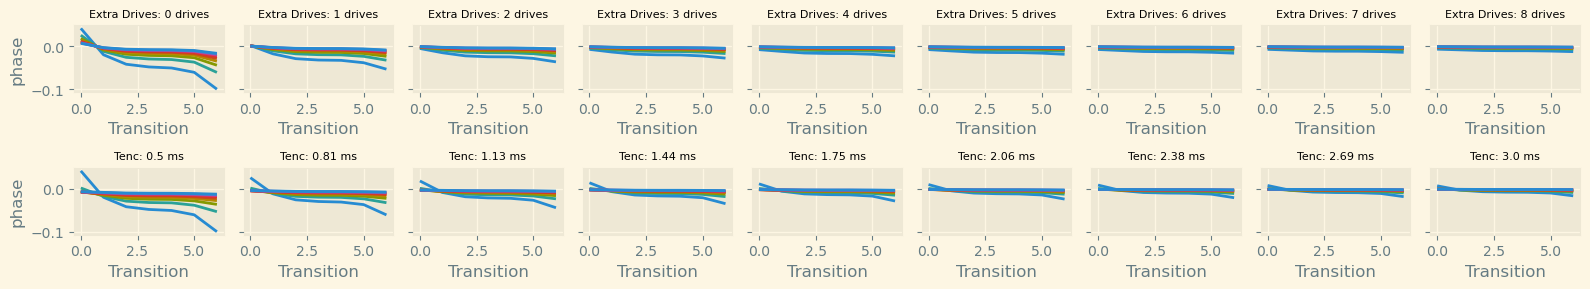

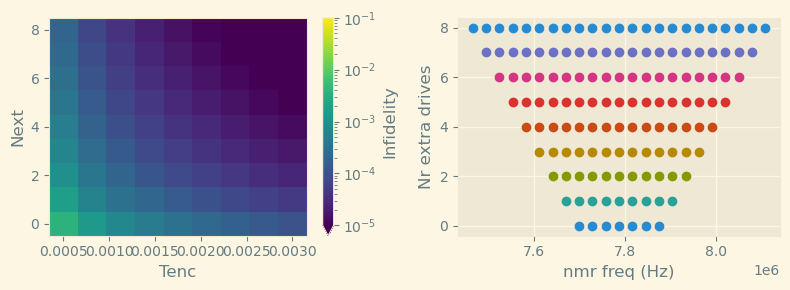

In [ ]:
plot_nmr_extend_experiment('./data/encode/Extra_drives_4.nc')

# EXP: Stark shift vs Extra drive vs 2nd order quadrupole 

In [ ]:
def run_ext_vs_iz3_experiment(Iz3_array, Next_array,
                          nmr_frequencies: np.ndarray,
                          observables: dict[str, qt.Qobj],
                          Tenc: float= 1e-3,
                          pulse_shape: str='square',
                          Trise: float = 0.2,
                          store_time_trace: list[str] = [],
                          dt = 5e-7,
                          nr_time_samples: int = 100):

    results, observable_names, observable_ops = set_up_data_arrays(
        sweep_params={'Iz3': Iz3_array, 'Next': Next_array},
        observables=observables,
        store_time_trace=store_time_trace,
        time_samples=nr_time_samples
    )

    results.attrs['pulse_shape'] = pulse_shape
    results.attrs['Tenc'] = Tenc
    results.attrs['nmr_frequencies'] = nmr_frequencies
    results.attrs['Trise'] = Trise
    results.attrs['dt'] = dt

    for ii, iz3 in enumerate(Iz3_array):
        for ij, Next in enumerate(Next_array):
            nmr_freqs = nmr_frequencies + (((np.arange(0, 8-1)-8/2+1))**2/2) * iz3
            splitting = np.mean(np.diff(nmr_freqs))
            ext_nmr_frequencies = np.array([*np.arange(nmr_freqs[0] - splitting * Next, nmr_freqs[0]-1, splitting), *nmr_freqs, *np.arange(nmr_freqs[-1] + splitting, nmr_freqs[-1] + splitting * (Next+1), splitting)])
            
            special_drive_dict = {
                    'nmr': {
                        'frequencies': ext_nmr_frequencies,  # Frequencies for the drive
                        'operator': qt.jmat(7/2, 'x'),  # Operators for the drive
                        'order': 1,  # order of the off-diagonals of the drive (Needed for RF)
                },
            }
        

            amp = 0.25/Tenc
            pulses = DriveSignal(drive_dict=special_drive_dict, pulse_shapes=pulse_shape_dict, dt=dt)
            pulses.pulse_shapes['sin_sq']['args']['Trise'] = Trise
            pulses.init_drive_signal_list()
            pulses.frame_rotation('nmr', -np.pi/2)
            pulses.global_pulse('nmr', T=Tenc, pulse_shape=pulse_shape, amp=amp)
            pulses.finish_pulse_sequence()
            Hdrive, time_array = pulses.get_drive_hamiltonian(nmr_freqs, cross_coupling_cutoff_frequency=None)
            result = qt.mesolve(Hdrive, qt.basis(dim, 0), time_array)

            # analysis
            final_state = result.states[-1]
            time_samples = np.linspace(0, len(time_array)-1, nr_time_samples, dtype=int) # resampling time evolution because they are not all the same length

            for iob, op in enumerate(observable_ops):
                if observable_names[iob] in store_time_trace:
                    exp_time_samples = []
                    for t in time_samples:
                        if observable_names[iob] == 'state':
                            state = result.states[t]
                            if state.type == 'ket':
                                state = qt.ket2dm(state)
                            exp_time_samples.append(state.full())
                        else:
                            exp_time_samples.append(qt.expect(op, result.states[t]))
                    results[observable_names[iob]][ii, ij] = exp_time_samples
                else:
                    if observable_names[iob] == 'state':
                        state = result.states[-1]
                        if state.type == 'ket':
                            state = qt.ket2dm(state)
                        results[observable_names[iob]][ii, ij] = state.full()
                    else:
                        results[observable_names[iob]][ii, ij] = qt.expect(op, final_state)
    return results




In [ ]:
# init

N = 9
Iz3_array = np.linspace(0, 1e2, N)
Next_array = np.arange(0, N)

observables = {
    'Fidelity': qt.ket2dm(target_state),
    'Ix': Ix,
    'Iz': Iz,
    'state': qt.identity(8)  # Identity operator to get the Hilbert space size
}

# run
experiment_name = f"Extra_drives_vs_iz3_smaller_range"
results= run_ext_vs_iz3_experiment(Iz3_array, Next_array,
                          nmr_frequencies=nmr_frequencies,
                            observables=observables,
                            pulse_shape='sin_sq',
                            Trise=Trise,
                            store_time_trace=['Iz', 'Ix', 'state']
)
save_experiment(results, experiment_name, folder)

Results saved to ./data/encode/Extra_drives_vs_iz3_smaller_range_0.nc


In [ ]:
def plot_extend_vs_iz3_experiment(results):
    import matplotlib.colors as mcolor
    if isinstance(results, str):
        results = xr.load_dataset(results)
        results['state'] = results.state_Re + 1j*results.state_Im

    fidelity = results['Fidelity']
    infidelity = (1-results['Fidelity'])
    infidelity = infidelity.rename('Infidelity')

    final_state = results.state.isel(t_idx=-1)
    phases = np.zeros((len(results.Iz3), len(results.Next), 7), dtype=np.complex128)
    for i in range(len(results.Iz3)):
        for j in range(len(results.Next)):
            phases[i, j] = np.angle(np.diag(final_state[i, j], 1))
    fig, axs = plt.subplots(2, len(results.Next), figsize=(16, 3), sharey=True)
    iz3s = results.Iz3.to_numpy()
    for i in range(len(results.Iz3)):
        plt.sca(axs[0, i])
        plt.title(f"Iz3: {np.round(iz3s[i], 2)}", fontdict={'fontsize': 8})

        plt.plot(np.arange(7), phases[i, :].T)
        # plt.legend(results.Iz3.to_numpy()*1e3)
        plt.xlabel('Transition')
    axs[0, 0].set_ylabel('phase')

    for i in range(len(results.Next)):
        plt.sca(axs[1, i])
        plt.title(f"Extra Drives: {results.Next[i].values} drives", fontdict={'fontsize': 8})
        plt.sca(axs[1, i])
        plt.plot(np.arange(7), phases[:, i].T)
        # plt.legend(results.Next.to_numpy())
        plt.xlabel('Transition')
    axs[1, 0].set_ylabel('phase')
    fig.tight_layout()
    fig2 ,axs2 = plt.subplots(1, 2, figsize = (8,3))
    # plt.title(f"Final Result: infidelity")
    infidelity.plot.pcolormesh(ax=axs2[0], norm=mcolors.LogNorm(vmin=1e-5, vmax=1e-1))
    
    splitting = np.mean(np.diff(nmr_frequencies))
    for inex, nex in enumerate(results.Next.to_numpy()):
        ext_nmr_frequencies = np.array([*np.arange(nmr_frequencies[0] - splitting * nex, nmr_frequencies[0]-1, splitting), *nmr_frequencies, *np.arange(nmr_frequencies[-1] + splitting, nmr_frequencies[-1] + splitting * (nex+1), splitting)])
        axs2[1].scatter(ext_nmr_frequencies, np.ones_like(ext_nmr_frequencies) * (inex))
    axs2[1].set_xlabel('nmr freq (Hz)')
    axs2[1].set_ylabel('Nr extra drives')
    fig2.tight_layout()
    plt.show()

c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


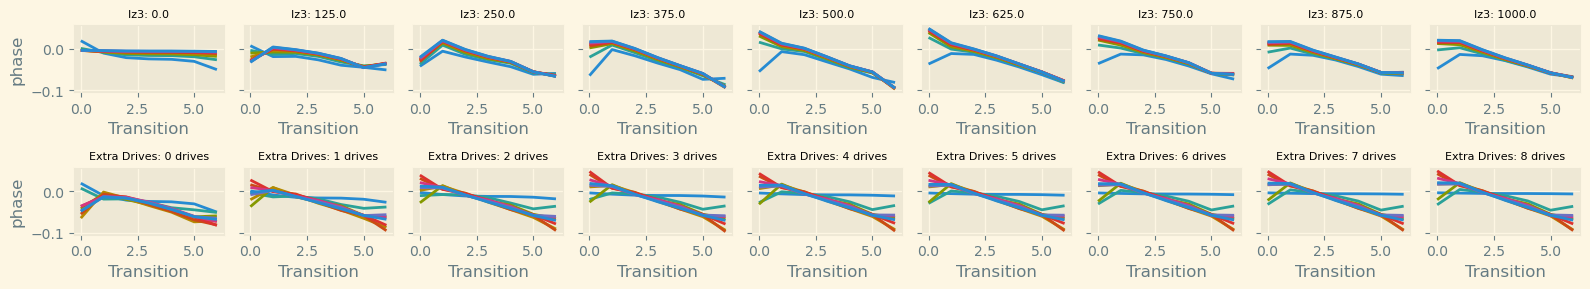

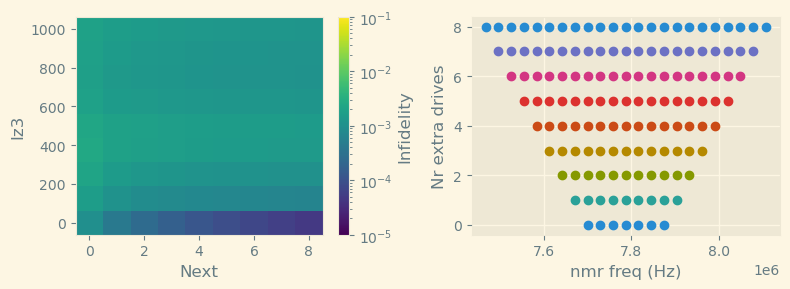

In [ ]:
plot_extend_vs_iz3_experiment('./data/encode/Extra_drives_vs_iz3_0.nc')

c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


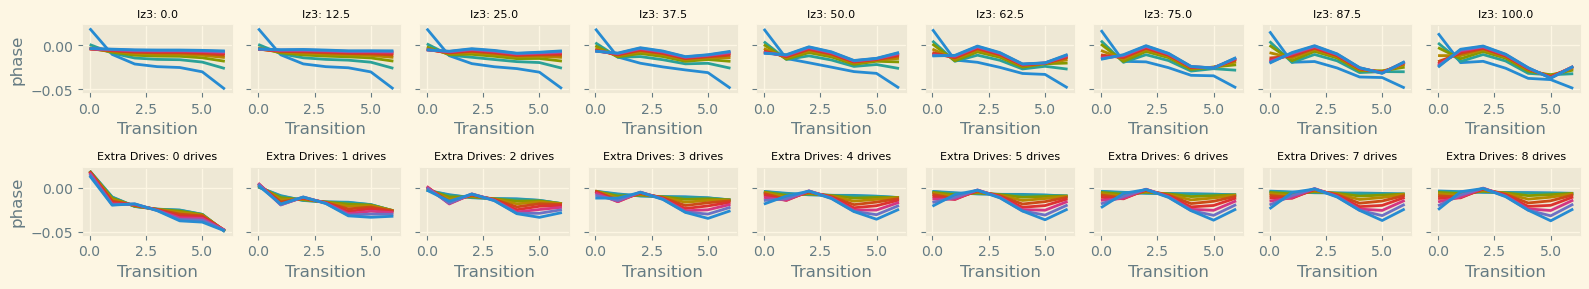

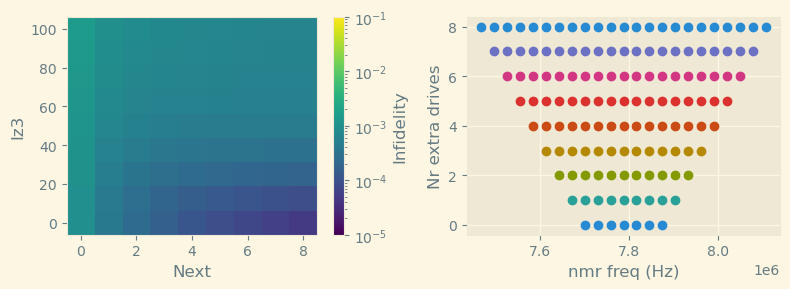

In [ ]:
plot_extend_vs_iz3_experiment('./data/encode/Extra_drives_vs_iz3_smaller_range_0.nc')

In [ ]:
splitting

np.float64(29166.666666666668)

# Analytic stark shift effects

In [ ]:
def stark_shift(amp, Det):
    return np.sign(Det) * (np.sqrt(Det**2 + amp**2) - np.abs(Det))
def stark_shift_global_drive(amp, splitting, index):
    shift = np.zeros_like(amp)
    for i in range(dim-1):
        shift += stark_shift(amp, splitting*(i - index))
    return shift

In [ ]:
shift = np.zeros_like(1)
shift

array(0)

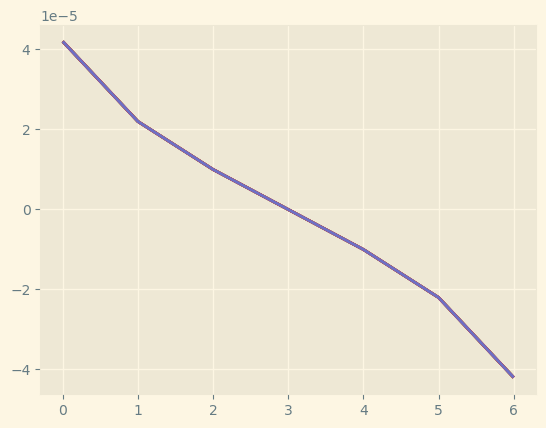

In [ ]:
plt.plot(df.T)

In [ ]:
amp_array = np.linspace(0.1, 3, 8)
Trise = 0.1
results = []
Tenc = []
time_arrays = []
for iamp, amp in enumerate(amp_array):
    base_amp = 1166.6666/7*amp# pi time 3 ms
    base_T = 1.5e-3/amp
    cross_coupling_cutoff = 0
    Tenc.append(base_T)
    
    offset_drive_dict = {
        'nmr': {
            'frequencies': nmr_frequencies,  # Frequencies for the drive
            'ops': nmr_ops,  # Operators for the drive
            'order': 1,  # order of the off-diagonals of the drive (Needed for RF)
        },
    }

    pulses = DriveSignal(drive_dict=offset_drive_dict, pulse_shapes=pulse_shape_dict, dt=1e-7)
    pulses.pulse_shapes['sin_sq']['args']['Trise'] = Trise
    pulses.init_drive_signal_list()
    pulses.frame_rotation('nmr', -np.pi/2)
    signal = pulses.pulse_shapes['sin_sq']['function'](np.arange(0, base_T, pulses.dt), base_T, **pulses.pulse_shapes['sin_sq']['args'])
    stark_shift_arrays = np.zeros((dim-1, len(signal)))
    for i in range(dim-1):
        stark_shift_arrays[i, :] = stark_shift_global_drive(signal*base_amp, np.mean(np.diff(nmr_frequencies)), i)

    pulses.global_pulse('nmr', T=base_T, pulse_shape='sin_sq', amp=base_amp, freq_mod_signal=stark_shift_arrays, square_freq_mod=False)
    pulses.finish_pulse_sequence()
    Hdrive, time_array = pulses.get_drive_hamiltonian(nmr_frequencies, cross_coupling_cutoff=cross_coupling_cutoff)
    time_arrays.append(time_array)
    result = qt.mesolve(Hdrive, qt.basis(dim, 0), time_array,)# e_ops=[Ix, Iy, Iz, qt.ket2dm(target_state)])
    results.append(result)

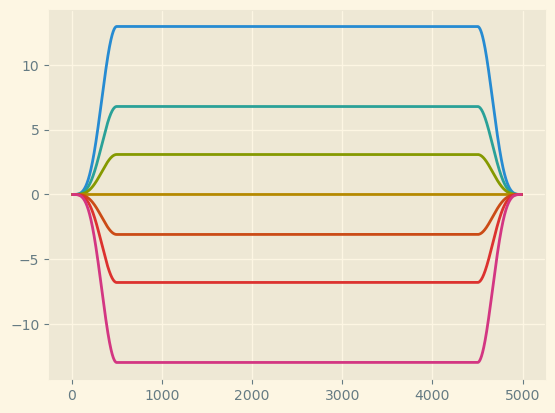

In [ ]:
plt.plot(stark_shift_arrays.T)

In [ ]:
np.mean(np.diff(nmr_frequencies))

np.float64(29166.666666666668)

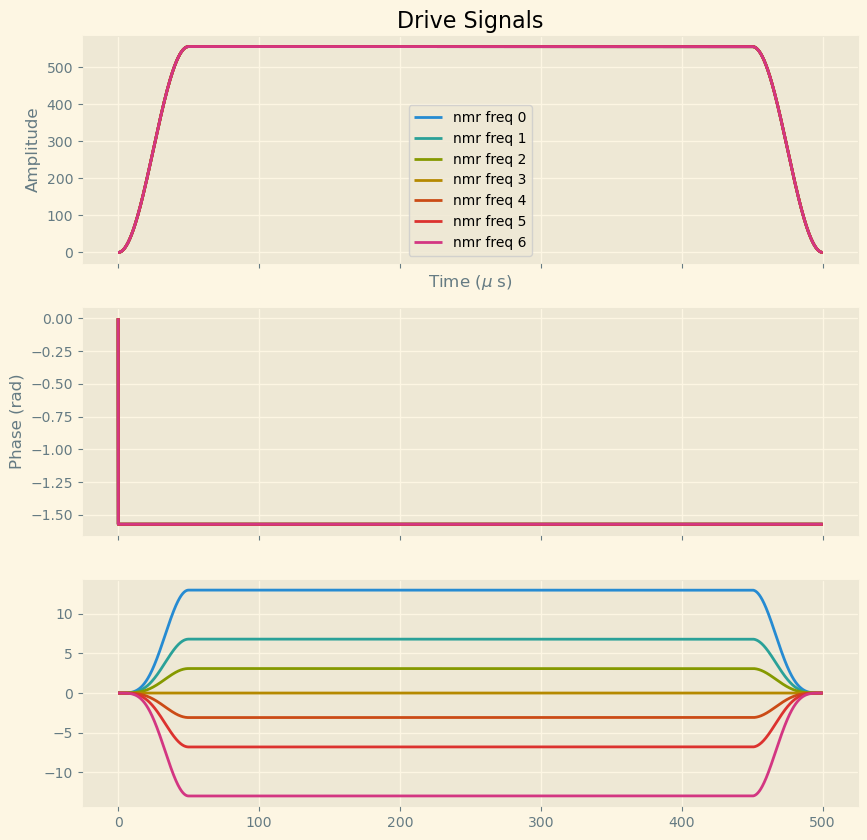

In [ ]:
pulses.plot_signal('nmr')
# plt.axhline(df*base_amp**2)

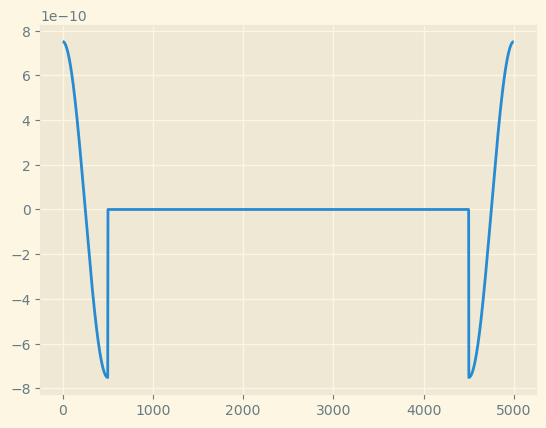

In [ ]:
plt.plot(np.diff(signal, 2)/splitting)

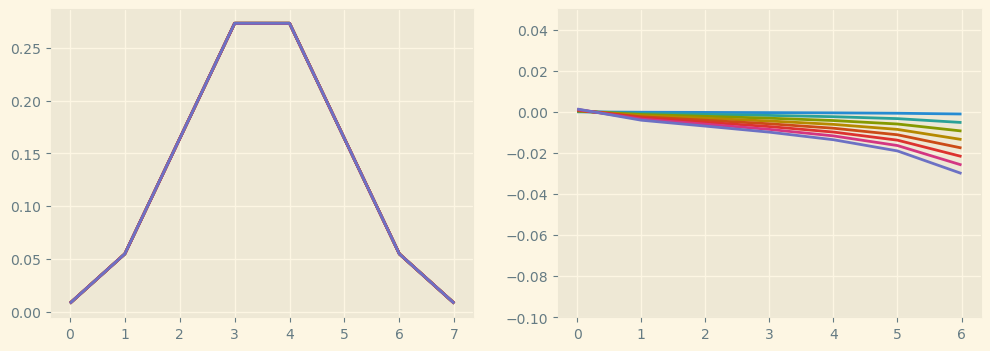

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ir, res in enumerate(results):
    final_state = qt.ket2dm(res.states[-1])
    axs[0].plot(np.abs(np.diag(final_state.full())))
    axs[1].plot(np.angle(np.diag(final_state.full(), 1)))
    axs[1].set_ylim(-0.1, 0.05)

# stark shift measurement?

In [503]:
nmr_frequencies = 7.7e6 + np.arange(-3, 4)*25e3
nmr_frequencies

array([7625000., 7650000., 7675000., 7700000., 7725000., 7750000.,
       7775000.])

In [504]:
np.diff(nmr_frequencies)

array([25000., 25000., 25000., 25000., 25000., 25000.])

In [505]:
ang/Tenc

2500.0

In [545]:
1/25e3

4e-05

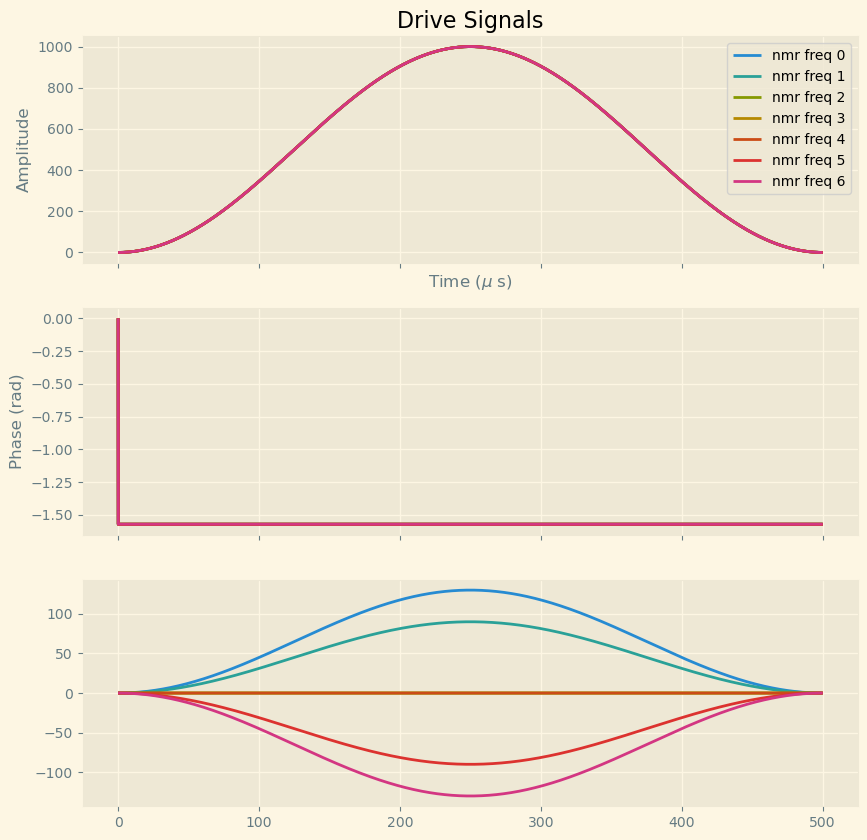

In [710]:
# amp_array = np.linspace(0.1, 3, 8)
Trise = 0.5
results = []
# Tenc = []
# time_arrays = []
# base_amp = 1166.6666/7*amp# pi time 3 ms
# base_T = 1.5e-3/amp
# Tenc.append(base_T)

Tenc = 0.5e-3
offset_drive_dict = {
    'nmr': {
        'frequencies': nmr_frequencies,  # Frequencies for the drive
        'ops': nmr_ops,  # Operators for the drive
        'order': 1,  # order of the off-diagonals of the drive (Needed for RF)
    },
}

superpos = np.sqrt(1/8) * qt.basis(8,0)
for i in range(1, 8):
    superpos += np.sqrt(1/8) * qt.basis(8, i)

pulses = DriveSignal(drive_dict=offset_drive_dict, pulse_shapes=pulse_shape_dict, dt=1e-8)
pulses.pulse_shapes['sin_sq']['args']['Trise'] = Trise
pulses.init_drive_signal_list()
pulses.frame_rotation('nmr', -np.pi/2)
# pulses.set_selfconsistent_detuning(ss_det-ss_det_2)
ang=0.25
pulses.global_pulse('nmr', T=Tenc, pulse_shape='sin_sq', amp=ang/Tenc, freq_mod_signal=-1*np.array([-65, -45, 0, 0, 0, 45, 65])/(ang/Tenc))
pulses.finish_pulse_sequence()
pulses.plot_signal('nmr')
Hdrive, time_array = pulses.get_drive_hamiltonian(nmr_frequencies,  cross_coupling_cutoff_frequency=None, cross_coupling_only=False)

# nz = 2
# init_state = np.sqrt(1/2)*(qt.basis(dim, nz) + qt.basis(dim, nz+1))

# test_op = np.zeros((dim, dim), dtype=np.complex128)
# test_op[1, 2] = 1
# test_op[2, 1] = 1
# test_op = qt.Qobj(test_op)
result = qt.mesolve(Hdrive, (qt.basis(8,0)+  1j*qt.basis(8,7))/np.sqrt(2),  time_array)


In [526]:
max(pulses.pulse_shapes['sin_sq']['function'](np.arange(0, Tenc, pulses.dt), Tenc, **pulses.pulse_shapes['sin_sq']['args']))

np.float64(1.1111111111111112)

In [712]:
qt.ket2dm(result.states[-1])

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.40019676e-02+0.j          3.51980310e-03-0.01592189j
   5.46511441e-02+0.01593642j  1.48412031e-02-0.05548022j
   5.54802189e-02+0.0148412j   1.59364195e-02-0.05465114j
   1.59218928e-02+0.0035198j   3.03576608e-17-0.01400197j]
 [ 3.51980310e-03+0.01592189j  1.89898800e-02+0.j
  -4.38343366e-03+0.0661509j   6.68183385e-02+0.00292963j
  -2.92963098e-03+0.06681834j  6.61508970e-02+0.00438343j
   5.37764278e-17+0.01898988j  1.59218928e-02-0.0035198j ]
 [ 5.46511441e-02-0.01593642j -4.38343366e-03-0.0661509j
   2.31447259e-01+0.j         -5.21836034e-03-0.2334367j
   2.33436698e-01-0.00521836j -8.32667268e-17-0.23144726j
   6.61508970e-02-0.00438343j -1.59364195e-02-0.05465114j]
 [ 1.48412031e-02+0.05548022j  6.68183385e-02-0.00292963j
  -5.21836034e-03+0.2334367j   2.35560894e-01+0.j
  -1.52655666e-16+0.23556089j  2.33436698e-01+0.00521836j
   2.92963098e-03+0.06681834j  5.54802189e-02-0.

In [713]:
angles = np.angle(np.diag(qt.ket2dm(result.states[-1]).full(),1))
angles

array([-1.35322863,  1.63696375, -1.5931471 ,  1.57079633, -1.54844555,
        1.5046289 , -1.78836403])

In [688]:
np.cumsum(angles)

array([ 0.1005648 ,  0.03051886, -0.13665416, -0.27006206, -0.38818222,
       -0.62159958, -0.94350338])

In [689]:
Ucorr = np.eye(8, dtype=np.complex128)
for i in range(1, 8):
    Ucorr[i, i] = np.exp(1j * np.cumsum(angles)[i-1])

Ucorr = qt.Qobj(Ucorr)


In [680]:
np.cumsum(angles)[i]

np.float64(-0.9435033783283826)

In [703]:
Ucorr

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[1.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.99494762+0.10039538j 0.        +0.j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.99953434+0.03051413j
  0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.99067734-0.13622923j 0.        +0.j         0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j         0.96375434-0.26679125j 0.        +0.j
  0.        +0.j         0.        +0.j        ]
 [0.        +0.j   

In [ ]:
np.exp(-1j* 0.1005648)

np.complex128(0.994947620664619+0.10039537904611714j)

In [714]:
qt.ket2dm(Ucorr*result.states[-1])

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.01400197+0.j          0.00190354-0.01619482j  0.05511198+0.01426137j
   0.02226087-0.05294119j  0.0495098 +0.02910491j  0.03543654-0.04455299j
   0.01089396+0.01213331j  0.01133626-0.00821853j]
 [ 0.00190354+0.01619482j  0.01898988+0.j         -0.0090025 +0.06568189j
   0.06425865+0.01854992j -0.0269323 +0.06122029j  0.05634796+0.0349294j
  -0.01255251+0.01424957j  0.01104677+0.01199435j]
 [ 0.05511198-0.01426137j -0.0090025 -0.06568189j  0.23144726+0.j
   0.03369719-0.23105069j  0.22451551+0.06413041j  0.09410046-0.21145434j
   0.05523691+0.03666114j  0.03624894-0.04389454j]
 [ 0.02226087+0.05294119j  0.06425865-0.01854992j  0.03369719+0.23105069j
   0.23556089+0.j         -0.03133255+0.23346778j  0.22479243+0.06315287j
  -0.0285562 +0.06047989j  0.04909694+0.02979608j]
 [ 0.0495098 -0.02910491j -0.0269323 -0.06122029j  0.22451551-0.06413041j
  -0.03133255-0.23346778j  0.23556089+0.j 

In [717]:
qt.ket2dm(target_state)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 7.81250000e-03+0.00000000e+00j  3.46944695e-18-2.06699321e-02j
   3.58013726e-02-2.08166817e-17j  3.46944695e-18-4.62193733e-02j
   4.62193733e-02-1.04083409e-17j  3.46944695e-18-3.58013726e-02j
   2.06699321e-02-1.73472348e-18j -3.46944695e-18-7.81250000e-03j]
 [ 3.46944695e-18+2.06699321e-02j  5.46875000e-02+0.00000000e+00j
   7.63278329e-17+9.47215285e-02j  1.22284968e-01-1.38777878e-17j
   4.85722573e-17+1.22284968e-01j  9.47215285e-02-1.38777878e-17j
   1.38777878e-17+5.46875000e-02j  2.06699321e-02-1.38777878e-17j]
 [ 3.58013726e-02+2.08166817e-17j  7.63278329e-17-9.47215285e-02j
   1.64062500e-01+0.00000000e+00j  1.38777878e-16-2.11803777e-01j
   2.11803777e-01+6.93889390e-17j  1.11022302e-16-1.64062500e-01j
   9.47215285e-02+5.55111512e-17j  6.93889390e-18-3.58013726e-02j]
 [ 3.46944695e-18+4.62193733e-02j  1.22284968e-01+1.38777878e-17j
   1.38777878e-16+2.11803777e-01j  2.73437

In [716]:
target_state = (-1j*np.pi/2*Iy).expm() * (qt.basis(8, 0)+ 1j*qt.basis(8, 7))/np.sqrt(2)

In [721]:
qt.fidelity(Ucorr*result.states[-1], target_state)

np.float64(0.9665983430425443)

In [507]:
def window_diff(array, window):
    diff = np.zeros_like(array)
    for i in range(len(array)):
        if i < window//2:
            diff[i] = np.mean(np.diff(array[0:i+window//2]))
        elif i >= len(array) - window//2:
            diff[i] = np.mean(np.diff(array[i-window//2:]))
        else:
            diff[i] = np.mean(np.diff(array[i - window//2:i + window//2]))
    return diff


In [508]:
def window_avg(array, window):
    avg = np.zeros_like(array)
    for i in range(len(array)):
        if i < window//2:
            avg[i] = np.mean(array[0:i+window//2], axis=0)
        elif i >= len(array) - window//2:
            avg[i] = np.mean(array[i-window//2:], axis=0)
        else:
            avg[i] = np.mean(array[i - window//2:i + window//2], axis=0)
    return avg
    

In [444]:
len(time_array)

100000

In [532]:
ix = np.abs(np.diag(qt.jmat(7/2, 'x').full(), 1))

In [ ]:
(0.25/Tenc)**2*(1/25e3*ix[1] + 1/50e3*ix[2] + 1/75e3*ix[3] + 1/100e3*ix[4] + 1/125e3*ix[5] + 1/150e3*ix[6])*1.1111
+ ix[1]*(0.25/Tenc)**2*(1/25e3 + 1/50e3+ 1/75e3 + 1/100e3 + 1/125e3 + 1/150e3)*1.1111

np.float64(12.272031907618016)

In [538]:
ix[0]*(0.25/Tenc)**2*(1/25e3 + 1/50e3+ 1/75e3 + 1/100e3 + 1/125e3 + 1/150e3)*1.1111 + \
ix[1]*(0.25/Tenc)**2*(-1/25e3 + 1/50e3 + 1/75e3 + 1/100e3 + 1/125e3 )*1.1111

np.float64(10.365988241484603)

In [ ]:
(0.25/Tenc)**2*(-1/25e3*ix[0] +  + 1/50e3*ix[2] + 1/75e3*ix[3] + 1/100e3*ix[4] + 1/125e3*ix[5] + 1/150e3*ix[6])*1.1111

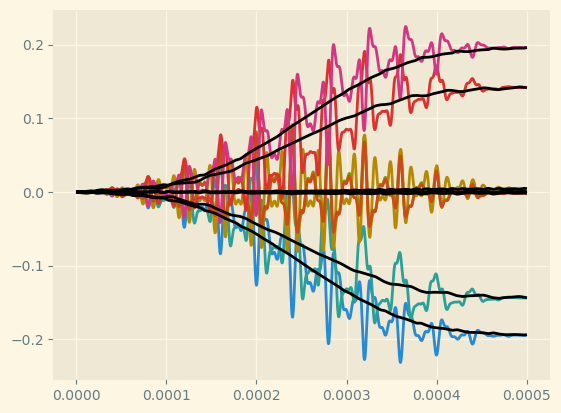

In [547]:
phase_list = []
for s in result.states:
    dm = qt.ket2dm(s)
    phases = np.angle(np.diag(dm.full(), 1))
    phase_list.append(phases)

phase_arr = np.array(phase_list)

plt.plot(time_array, phase_arr)
wavg = window_avg(phase_arr, window=20000)
plt.plot(time_array, wavg, c='k')


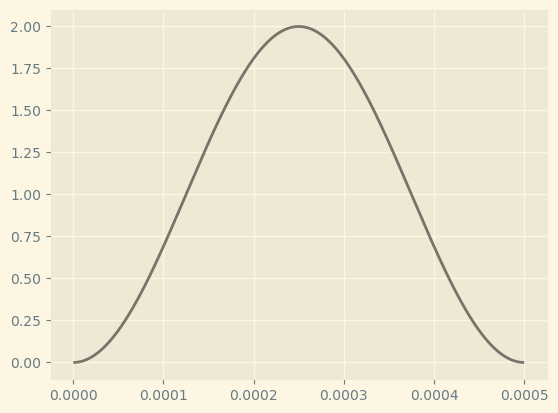

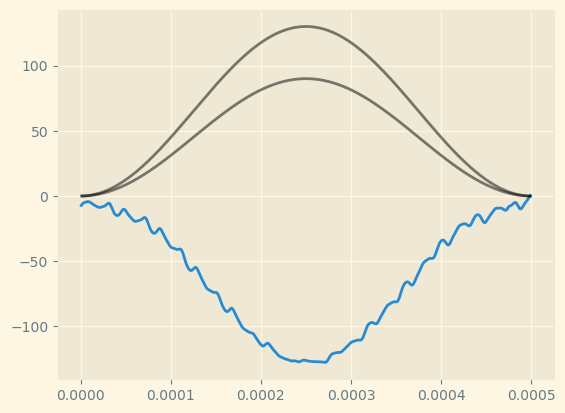

In [579]:
plt.figure()
plt.plot(time_array[1:], window_avg((np.diff(wavg, axis=0)/np.diff(time_array).reshape(len(time_array)-1, 1)/2/np.pi)[:,0], window=5000))

plt.plot(time_array[1:], 65*(pulses.pulse_shapes['sin_sq']['function'](time_array[1:], time_array[-1], **pulses.pulse_shapes['sin_sq']['args'])), c='k', alpha=0.5)
plt.plot(time_array[1:], 45*(pulses.pulse_shapes['sin_sq']['function'](time_array[1:], time_array[-1], **pulses.pulse_shapes['sin_sq']['args'])), c='k', alpha=0.5)

In [551]:
ss_det_2 = np.angle(np.diag(qt.ket2dm(result.states[-1]).full(),1))/2/np.pi/Tenc
ss_det_2

array([-61.91096238, -45.78570249,   0.12020581,   1.34867191,
        -0.58135075,  45.07968871,  62.37543846])

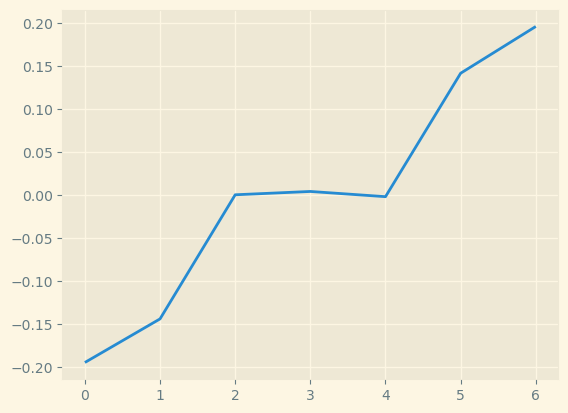

In [550]:
plt.plot(np.angle(np.diag(qt.ket2dm(result.states[-1]).full(),1)))

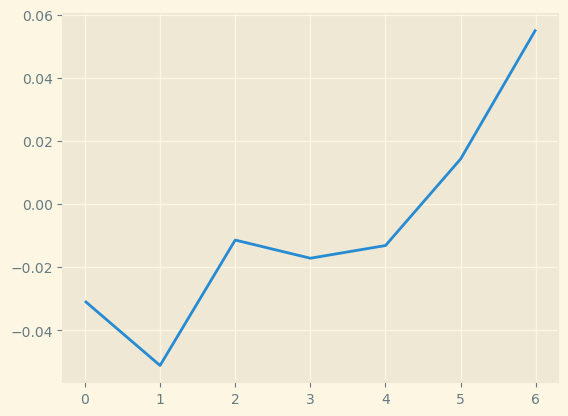

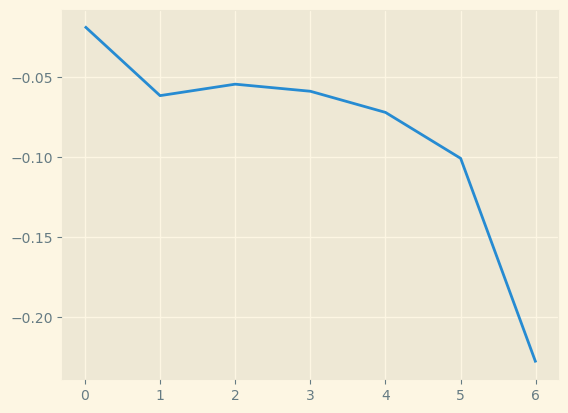

In [376]:
plt.plot(np.angle(np.diag(qt.ket2dm(result.states[-1]).full(),1)))

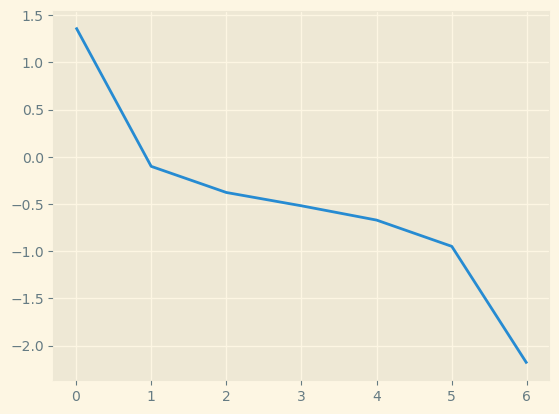

In [341]:
plt.plot(np.angle(np.diag(qt.ket2dm(result.states[-1]).full(),1)))

In [ ]:
def stark_shift(amp, Det):
    return amp**2/4()

In [309]:
stark_shift(ang/Tenc, 0)

np.float64(0.0)

In [310]:
stark_shift(ang/Tenc, np.mean(np.diff(nmr_frequencies)))

np.float64(0.47618658898500144)

In [311]:
def stark_shift_global_drive(amp, splitting, index):
    if not isinstance(index, (list, np.ndarray)):
        index = np.array([index])
    elif not isinstance(index, np.ndarray):
        index = np.array(index)
    shift = np.zeros_like(index, dtype=float)

    for ind, val in enumerate(index):
        ss = 0
        for i in range(dim-1):
            ss += stark_shift(amp, splitting*(i - val))
        shift[ind] = ss
    return shift

In [312]:
stark_shift_global_drive(ang/Tenc, np.mean(np.diff(nmr_frequencies)), np.arange(7))


array([ 1.16666204,  0.61111039,  0.27777757,  0.        , -0.27777757,
       -0.61111039, -1.16666204])

In [313]:
result.states[-1]

Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[ 9.99997995e-01-1.49567260e-03j]
 [ 2.58802273e-04-1.30617262e-03j]
 [-7.25466914e-07-1.13440654e-06j]
 [-1.56629396e-09-2.81192953e-09j]
 [ 8.38569256e-12-7.18338127e-12j]
 [ 1.81678191e-11-6.19756733e-12j]
 [ 2.56345651e-14-1.02329023e-14j]
 [ 1.06965015e-17+5.75003264e-18j]]

In [215]:
phase = []
pops = []
for state in result.states:
    dm = qt.ket2dm(state)
    pops.append(np.real(np.diag(dm.full()))[nz:nz+2])
    p = np.angle(np.diag(dm.full(), 1))[nz]
    if p > 0.5:
        phase.append(p - 2*np.pi)
    else:
        phase.append(p)


In [216]:
np.max(pulses.pulse_shapes['sin_sq']['function'](time_array, time_array[-1], **pulses.pulse_shapes['sin_sq']['args']))

np.float64(1.1111111111111112)

In [217]:
def moving_avg(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

In [219]:
ang/Tenc*1.1111111111111112

9.25925925925926

In [220]:
np.diff(-delta/2)

NameError: name 'delta' is not defined

np.float64(680.4000172259745)

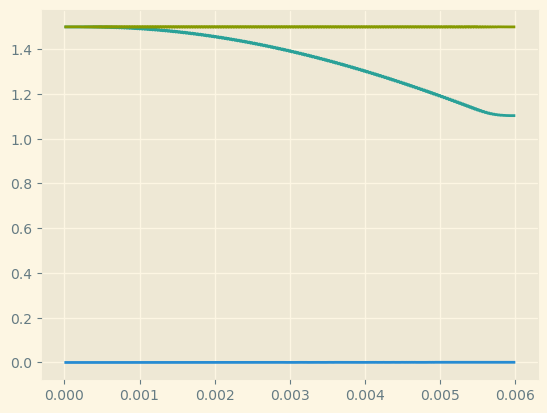

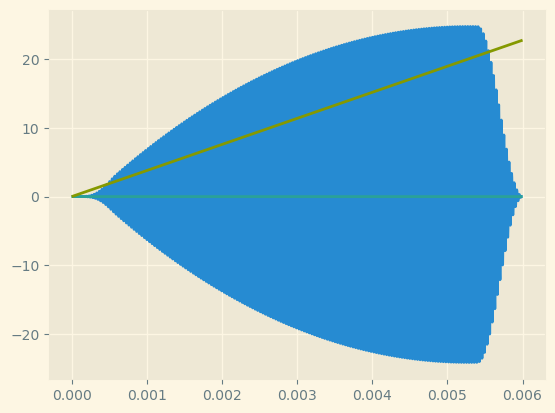

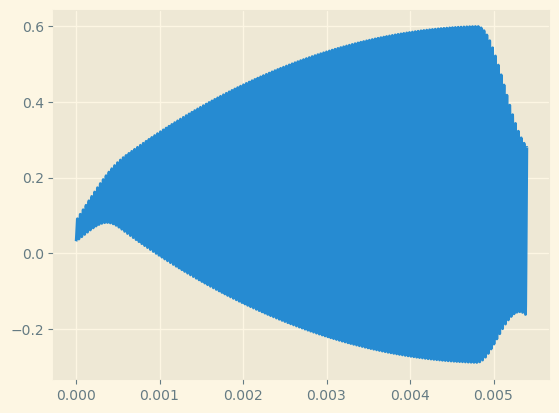

In [222]:
plt.plot(time_array, phase)
plt.plot(time_array, np.array(pops)*3)
plt.figure()
diff = np.diff(phase)/np.diff(time_array)
plt.plot(time_array[:-1], diff)
plt.plot(time_array, 0.001469723654736*time_array)
plt.plot(time_array, 3.8e3*time_array)
# plt.xlim(0.002, 0.003)
# plt.ylim(-10000, 10000)
plt.figure()
avg_diff = moving_avg(diff, 6000)

plt.plot(time_array[:-(len(time_array)-len(avg_diff))], avg_diff)


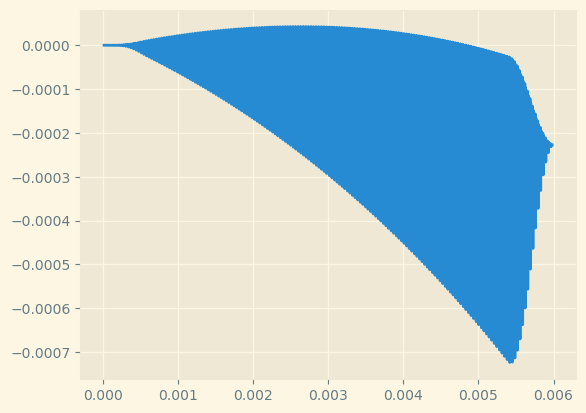

In [176]:
plt.plot(time_array, phase)

In [ ]:
]

In [1]:
0.236/1.236

0.19093851132686082

In [ ]:
np.cos()

np.float64(0.7861297602813418)

In [524]:
1.3325488190509667*2/np.pi

0.8483269258529158

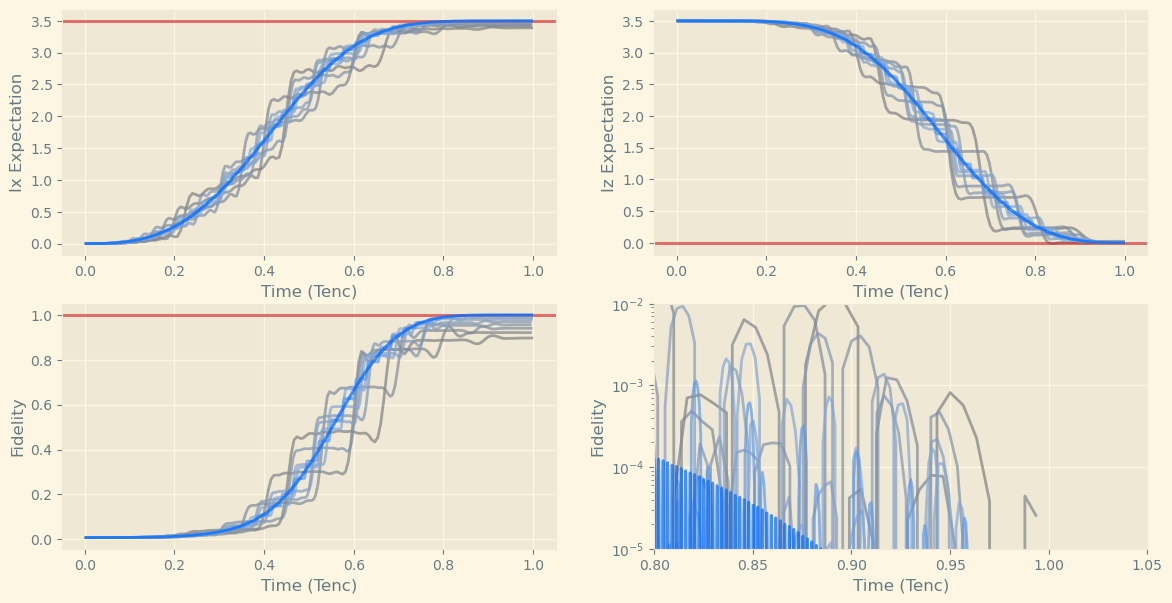

In [ ]:
colors = cmap(np.linspace(0, 1, len(results)))
fig, axs = plt.subplots(2, 2, figsize=(14, 7))
for ir, r in enumerate(results):
    result = results[-(ir+1)]
    axs[0, 0].plot(time_arrays[-(ir+1)]/Tenc[-(ir+1)],result.expect[0], color=colors[ir], alpha=0.7)
    axs[0, 0].axhline(3.5, color='tab:red', alpha=0.1)
    axs[0, 0].set_xlabel('Time (Tenc)')
    axs[0, 0].set_ylabel('Ix Expectation')
    axs[0, 1].plot(time_arrays[-(ir+1)]/Tenc[-(ir+1)],result.expect[2], color=colors[ir], alpha=0.7)
    axs[0, 1].set_ylabel('Iz Expectation')
    axs[0, 1].set_xlabel('Time (Tenc)')
    axs[0, 1].axhline(0, color='tab:red', alpha=0.1)

    axs[1, 0].plot(time_arrays[-(ir+1)]/Tenc[-(ir+1)],result.expect[3], color=colors[ir], alpha=0.7)
    axs[1, 0].set_ylabel('Fidelity')
    axs[1, 0].set_xlabel('Time (Tenc)')
    axs[1, 0].axhline(1, color='tab:red', alpha=0.1)

    diff_time_array = (time_arrays[-(ir+1)][:-1] + time_arrays[-(ir+1)][1:])/2
    axs[1, 1].semilogy(diff_time_array/Tenc[-(ir+1)]  , np.diff(result.expect[3]), color=colors[ir], alpha=0.7)
    axs[1, 1].set_ylabel('Fidelity')
    axs[1, 1].set_xlabel('Time (Tenc)')
    axs[1, 1].set_xlim(0.8, 1.05)
    axs[1, 1].set_ylim(1e-5, 1e-2)


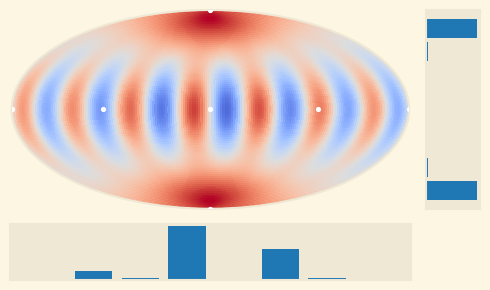

In [ ]:
plotQB  = CatQubit()
plotQB.update_state(qt.ket2dm((-1j*Iy**2*np.pi/2).expm() * (1j*Iz*np.pi/20).expm() * (1j*Iy**2*np.pi/2).expm() * (qt.basis(8, 0) +  qt.basis(8, 7))/np.sqrt(2)))
plotQB.plot_state()


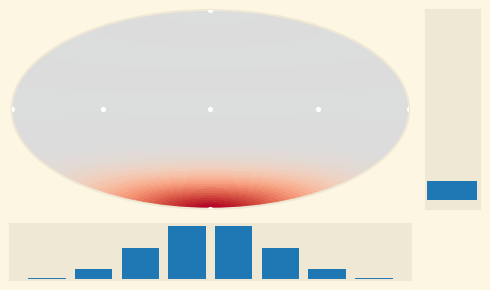

In [ ]:
plotQB  = CatQubit()
plotQB.update_state(qt.ket2dm((-1j*Iy**2*np.pi/2).expm() * (1j*Iz*np.pi).expm() * (1j*Iy**2*np.pi/2).expm() * qt.basis(8, 0)))
plotQB.plot_state()


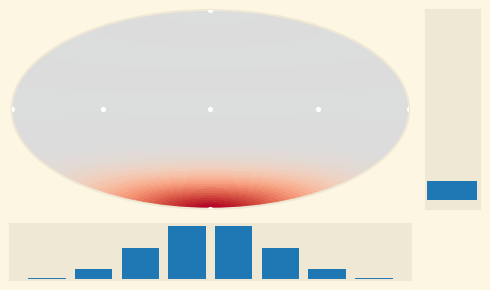

In [ ]:
plotQB  = CatQubit()
plotQB.update_state(qt.ket2dm((-1j*Iy**2*np.pi/2).expm() * (1j*Iy**2*np.pi/2).expm() * qt.basis(8, 0)))
plotQB.plot_state()


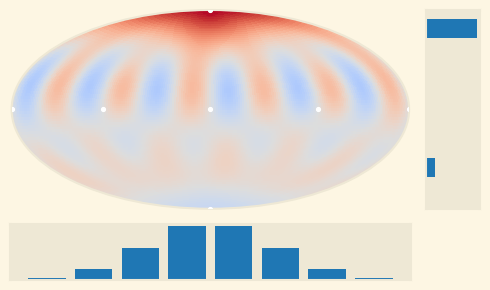

In [ ]:
plotQB  = CatQubit()
plotQB.update_state(qt.ket2dm((-1j*Iy**2*np.pi/2).expm() * (1j*Iz*np.pi/10).expm() * (1j*Iy**2*np.pi/2).expm() * qt.basis(8, 7)))
plotQB.plot_state()

# Ix^2 decoding and Iz/Iz^2 errors

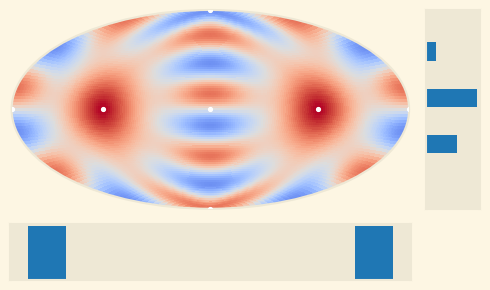

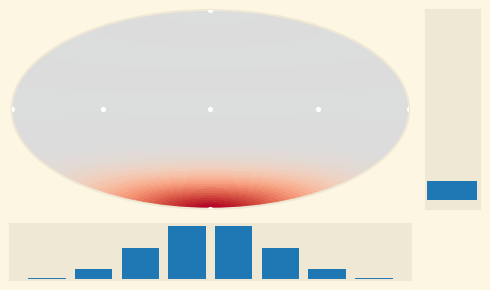

In [ ]:
QBtest  = CatQubit()
QBtest.encode()
QBtest.LRx_gate(np.pi/2)
QBtest.LRz_gate(np.pi/2)
QBtest.plot_state()
quad_decode = (-1j*np.pi/2 *Iy**2).expm()
# QBtest.phase_error(np.pi/15, 0)

QBtest.update_state(quad_decode.dag() * QBtest.state * quad_decode)
QBtest.plot_state()

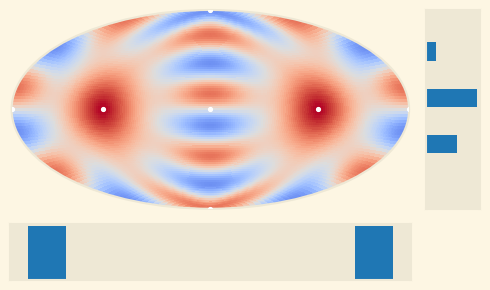

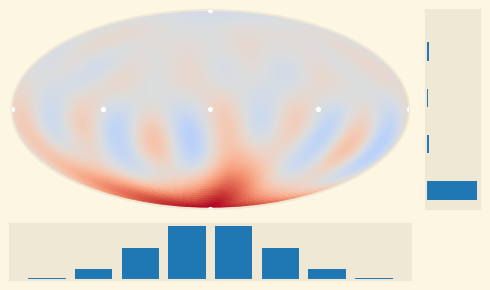

In [ ]:
QBtest  = CatQubit()
QBtest.encode()
QBtest.LRx_gate(np.pi/2)
QBtest.LRz_gate(np.pi/2)
QBtest.plot_state()
quad_decode = (-1j  *np.pi/2 * Iy**2).expm()
QBtest.phase_error(np.pi/15, np.pi/12)

QBtest.update_state(quad_decode.dag() * QBtest.state * quad_decode)
QBtest.plot_state()

In [ ]:
5.5*1.4

7.699999999999999

# propagator optimalisation

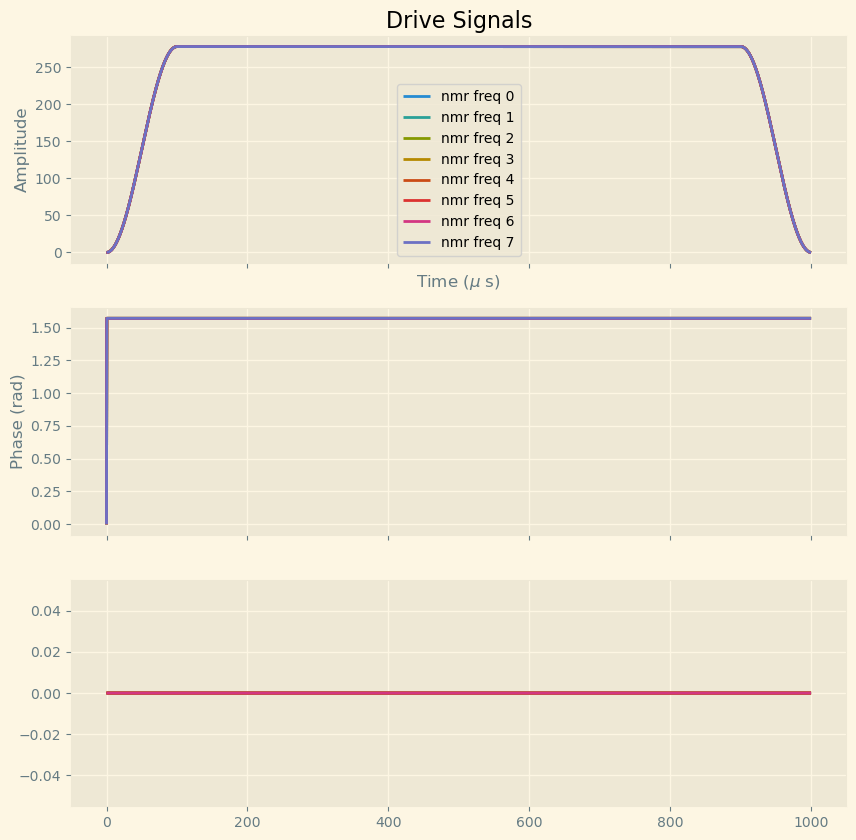

2500 2500


np.float64(0.9975141841167594)

In [ ]:
Tenc = 1e-3
amp  = 0.25/Tenc
fq = 25e3
fz = 5.5e6*1.4
nmr_frequencies = fz + np.arange(-3, 5)*fq

drive_dict = {
    'nmr':{
        'frequencies': nmr_frequencies,
        'operator': qt.jmat(7/2, 'x'),
        'order': 1,
    }
}
PulseSeq = DriveSignal(drive_dict=drive_dict, pulse_shapes=pulse_shape_dict, dt=4e-7)
PulseSeq.init_drive_signal_list()
PulseSeq.frame_rotation('nmr', np.pi/2)
PulseSeq.global_pulse('nmr', T=Tenc, pulse_shape='sin_sq', amp=amp)
PulseSeq.finish_pulse_sequence()
PulseSeq.plot_signal('nmr')
H, time_array = PulseSeq.get_drive_hamiltonian(nmr_frequencies)
print(len(H[0][1]), len(time_array))

# reshape H's because needed for qt.propagator
Hlist = []
for i in range(len(time_array)):
    Ht = 0*qt.identity(8)
    for j in range(len(H)):
        Ht += H[j][0]*H[j][1][i]
    Hlist.append(Ht)

U_list = qt.propagator(Hlist, time_array)
fid = qt.process_fidelity(U_list[-1], target_U)
fid

In [ ]:
U[-1]

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.08839145 -0.23405374 -0.40515187 -0.52257742 -0.52263742 -0.40520357
  -0.23403156 -0.08837965]
 [ 0.23405374  0.44207687  0.45852673  0.1970719  -0.19690551 -0.4586436
  -0.44215636 -0.23403156]
 [-0.40515187 -0.45852673 -0.08769606  0.34089027  0.34116724 -0.08747003
  -0.4586436  -0.40520357]
 [ 0.52257742  0.1970719  -0.34089027 -0.26378561  0.26342234  0.34116724
  -0.19690551 -0.52263742]
 [-0.52263742  0.19690551  0.34116724 -0.26342234 -0.26378561  0.34089027
   0.1970719  -0.52257742]
 [ 0.40520357 -0.4586436   0.08747003  0.34116724 -0.34089027 -0.08769606
   0.45852673 -0.40515187]
 [-0.23403156  0.44215636 -0.4586436   0.19690551  0.1970719  -0.45852673
   0.44207687 -0.23405374]
 [ 0.08837965 -0.23403156  0.40520357 -0.52263742  0.52257742 -0.40515187
   0.23405374 -0.08839145]]

In [ ]:
-(1j*np.pi/2 * Iy).expm()

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.08838835 -0.23385359 -0.40504629 -0.52291252 -0.52291252 -0.40504629
  -0.23385359 -0.08838835]
 [ 0.23385359  0.44194174  0.45927933  0.19764235 -0.19764235 -0.45927933
  -0.44194174 -0.23385359]
 [-0.40504629 -0.45927933 -0.08838835  0.3423266   0.3423266  -0.08838835
  -0.45927933 -0.40504629]
 [ 0.52291252  0.19764235 -0.3423266  -0.26516504  0.26516504  0.3423266
  -0.19764235 -0.52291252]
 [-0.52291252  0.19764235  0.3423266  -0.26516504 -0.26516504  0.3423266
   0.19764235 -0.52291252]
 [ 0.40504629 -0.45927933  0.08838835  0.3423266  -0.3423266  -0.08838835
   0.45927933 -0.40504629]
 [-0.23385359  0.44194174 -0.45927933  0.19764235  0.19764235 -0.45927933
   0.44194174 -0.23385359]
 [ 0.08838835 -0.23385359  0.40504629 -0.52291252  0.52291252 -0.40504629
   0.23385359 -0.08838835]]

In [ ]:
U[-1]

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.08839145 -0.23405374 -0.40515187 -0.52257742 -0.52263742 -0.40520357
  -0.23403156 -0.08837965]
 [ 0.23405374  0.44207687  0.45852673  0.1970719  -0.19690551 -0.4586436
  -0.44215636 -0.23403156]
 [-0.40515187 -0.45852673 -0.08769606  0.34089027  0.34116724 -0.08747003
  -0.4586436  -0.40520357]
 [ 0.52257742  0.1970719  -0.34089027 -0.26378561  0.26342234  0.34116724
  -0.19690551 -0.52263742]
 [-0.52263742  0.19690551  0.34116724 -0.26342234 -0.26378561  0.34089027
   0.1970719  -0.52257742]
 [ 0.40520357 -0.4586436   0.08747003  0.34116724 -0.34089027 -0.08769606
   0.45852673 -0.40515187]
 [-0.23403156  0.44215636 -0.4586436   0.19690551  0.1970719  -0.45852673
   0.44207687 -0.23405374]
 [ 0.08837965 -0.23403156  0.40520357 -0.52263742  0.52257742 -0.40515187
   0.23405374 -0.08839145]]

In [ ]:
H[0]

[Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
 Qobj data =
 [[0.         1.32287566 0.         0.         0.         0.
   0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.        ]],
 array([ 0.00000000e+00+0.j        ,  2.25085171e-01-0.47833034j,
         1.22869532e+00-1.58402446j, ..., -2.02555328e+00-4.30451983j,
        -4.75987657e-01-2.12944637j, -3.13626282e-14-0.55121544j]

In [ ]:
time_array

array([0.000e+00, 4.000e-07, 8.000e-07, ..., 9.988e-04, 9.992e-04,
       9.996e-04], shape=(2500,))

In [ ]:
H

[[Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
  Qobj data =
  [[0.         1.32287566 0.         0.         0.         0.
    0.         0.        ]
   [0.         0.         0.         0.         0.         0.
    0.         0.        ]
   [0.         0.         0.         0.         0.         0.
    0.         0.        ]
   [0.         0.         0.         0.         0.         0.
    0.         0.        ]
   [0.         0.         0.         0.         0.         0.
    0.         0.        ]
   [0.         0.         0.         0.         0.         0.
    0.         0.        ]
   [0.         0.         0.         0.         0.         0.
    0.         0.        ]
   [0.         0.         0.         0.         0.         0.
    0.         0.        ]],
  array([ 0.00000000e+00+0.j        ,  2.25085171e-01-0.47833034j,
          1.22869532e+00-1.58402446j, ..., -2.02555328e+00-4.30451983j,
         -4.75987657e-01-2.12944637j, -3.1362

In [178]:
import scipy.optimize as opt

In [239]:
def snap_and_infid(snap_array, U, target_U):
    Usnap = np.zeros((len(snap_array), len(snap_array)), dtype=np.complex128)
    for i in range(len(snap_array)):    
        Usnap[i, i] = np.exp(1j * snap_array[i])
    Usnap = qt.Qobj(Usnap) 
    return 1-qt.process_fidelity(Usnap.dag()*U*Usnap, target_U)

def opt_process_fidelity(U, target_U):
    n = U.full().shape[0]
    res = opt.minimize(snap_and_infid, x0=(np.zeros(n)), args=(U, target_U))
    return res.fun, res.x 


In [ ]:
np.diff(nmr_frequencies)

array([25000., 25000., 25000., 25000., 25000., 25000.])

In [181]:
Tenc = 1.5e-3
amp  = 0.25/Tenc
fq = 25e3
fz = 5.5e6*1.4
nmr_frequencies = fz + np.arange(-3, 4)*fq

def optimize_detuning(detuning_array_and_amp):

    detuning_array = detuning_array_and_amp[:-1]
    amp_scale = detuning_array_and_amp[-1]

    drive_dict = {
        'nmr':{
            'frequencies': nmr_frequencies,
            'operator': qt.jmat(7/2, 'x'),
            'order': 1,
        }
    }

    PulseSeq = DriveSignal(drive_dict=drive_dict, pulse_shapes=pulse_shape_dict, dt=4e-7)
    PulseSeq.init_drive_signal_list()
    PulseSeq.frame_rotation('nmr', np.pi/2)
    PulseSeq.set_selfconsistent_detuning(detuning_array)
    
    # signal = pulses.pulse_shapes['sin_sq']['function'](np.arange(0, Tenc, PulseSeq.dt), Tenc, **pulses.pulse_shapes['sin_sq']['args'])
    # stark_shift_arrays = np.zeros((dim-1, len(signal)))
    # for i in range(dim-1):
    #     stark_shift_arrays[i, :] = stark_shift_global_drive(signal*amp, np.mean(np.diff(nmr_frequencies)), i)*detuning_array[i]

    PulseSeq.global_pulse('nmr', T=Tenc, pulse_shape='sin_sq', amp=amp*amp_scale)
    PulseSeq.finish_pulse_sequence()
    # PulseSeq.plot_signal('nmr')
    H, time_array = PulseSeq.get_drive_hamiltonian(nmr_frequencies)
    # print(len(H[0][1]), len(time_array))

    # reshape H's because needed for qt.propagator
    Hlist = []
    for i in range(len(time_array)):
        Ht = 0*qt.identity(8)
        for j in range(len(H)):
            Ht += H[j][0]*H[j][1][i]
        Hlist.append(Ht)

    U_list = qt.propagator(Hlist, time_array)
    infid, snap = opt_process_fidelity(U_list[-1], target_U)
    # print(snap)
    return infid

opt.minimize(optimize_detuning, x0=(*np.ones(7)*0, 1), bounds=[*[(-300, 300)]*7, (-0.95, 1.05)], method='Nelder-Mead')

KeyboardInterrupt: 

In [ ]:
1-0.001712290945354078

0.9982877090546459

In [ ]:
optimize_detuning(1e-4*np.ones(7))

[ 2.75045498e-04  1.96418528e-04  1.17784005e-04  3.92613436e-05
 -3.92762706e-05 -1.17806383e-04 -1.96448357e-04 -2.75075352e-04]


np.float64(0.002379387608941519)

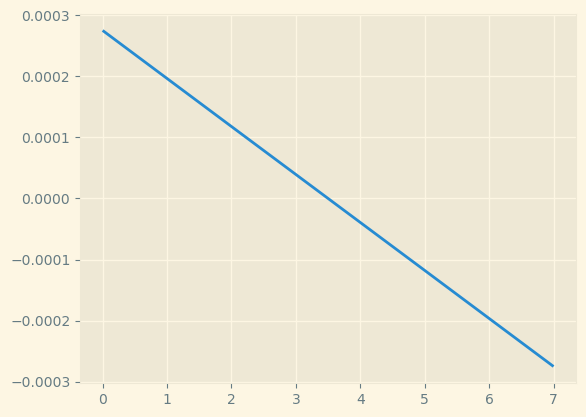

In [ ]:
plt.plot([2.75045498e-04,  1.96418528e-04,  1.17784005e-04,  3.92613436e-05, -3.92762706e-05, -1.17806383e-04, -1.96448357e-04, -2.75075352e-04])

In [ ]:
PulseSeq = DriveSignal(drive_dict=drive_dict, pulse_shapes=pulse_shape_dict, dt=4e-7)
PulseSeq.init_drive_signal_list()
PulseSeq.frame_rotation('nmr', np.pi/2)

PulseSeq.global_pulse('nmr', T=Tenc, pulse_shape='sin_sq', amp=amp, freq_mod_signal=detuning_arr)
PulseSeq.finish_pulse_sequence()

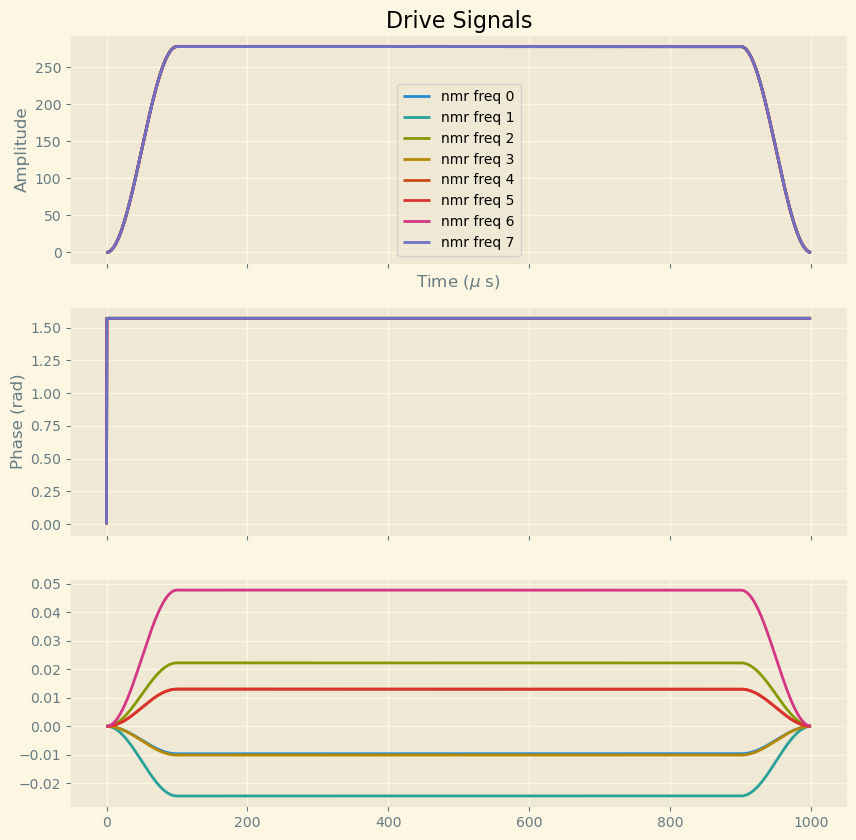

In [ ]:
PulseSeq.plot_signal('nmr')

# grape

In [ ]:
import qutip.control.grape as grape

In [ ]:
# get ops for grape
Ix = qt.jmat(7/2, 'x')
Iy = qt.jmat(7/2, 'y')
Hops = []
for i in range(7):
    op = np.zeros((8, 8), dtype=np.complex128  )
    op[i+1, i] = Ix.full()[i+1, i]
    op[i, i+1] = Ix.full()[i, i+1]
    Hops.append(qt.Qobj(op))
    op = np.zeros((8, 8), dtype=np.complex128  )
    op[i+1, i] = Iy.full()[i+1, i]
    op[i, i+1] = Iy.full()[i, i+1]
    Hops.append(qt.Qobj(op))

In [ ]:
# get ops for grape
Ix = qt.jmat(7/2, 'x')
Iy = qt.jmat(7/2, 'y')
Hops = []
times = np.arange(0, Tenc, 4e-7)
frequencies = np.arange(-3, 4)*25e3
for i in range(7):
    op = np.zeros((8, 8), dtype=np.complex128  )
    op[i+1, i] = Ix.full()[i+1, i]
    op[i, i+1] = Ix.full()[i, i+1]
    Hops.append([qt.Qobj(op), np.cos(2*np.pi*frequencies[i]*times)])
    op = np.zeros((8, 8), dtype=np.complex128  )
    op[i+1, i] = Iy.full()[i+1, i]
    op[i, i+1] = Iy.full()[i, i+1]
    Hops.append([qt.Qobj(op), np.sin(2*np.pi*frequencies[i]*times)])

In [ ]:
Hops[0][0]

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.         1.32287566 0.         0.         0.         0.
  0.         0.        ]
 [1.32287566 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[306250.      0.      0.      0.      0.      0.      0.      0.]
 [     0. 156250.      0.      0.      0.      0.      0.      0.]
 [     0.      0.  56250.      0.      0.      0.      0.      0.]
 [     0.      0.      0.   6250.      0.      0.      0.      0.]
 [     0.      0.      0.      0.   6250.      0.      0.      0.]
 [     0.      0.      0.      0.      0.  56250.      0.      0.]
 [     0.      0.      0.      0.      0.      0. 156250.      0.]
 [     0.      0.      0.      0.      0.      0.      0. 306250.]]

In [ ]:
Hops[0][0]

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.         1.32287566 0.         0.         0.         0.
  0.         0.        ]
 [1.32287566 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

In [ ]:
np.real(np.diff(np.diag(((Iz**2/2)*25e3).full())))

array([-75000., -50000., -25000.,      0.,  25000.,  50000.,  75000.])

## Different rotating frame
We just go in the SU(2) rotating frame so that we only have the Quadropole splitting

In [ ]:
plt.style.use('dark_background')

In [ ]:
def reorder_freqs(freqs, fft):
    freqs_n = np.array([*freqs[(len(freqs)//2):], *freqs[:(len(freqs)//2)]])
    fft_n = np.array([*fft[(len(fft)//2):], *fft[:(len(fft)//2)]])
    return freqs_n, fft_n

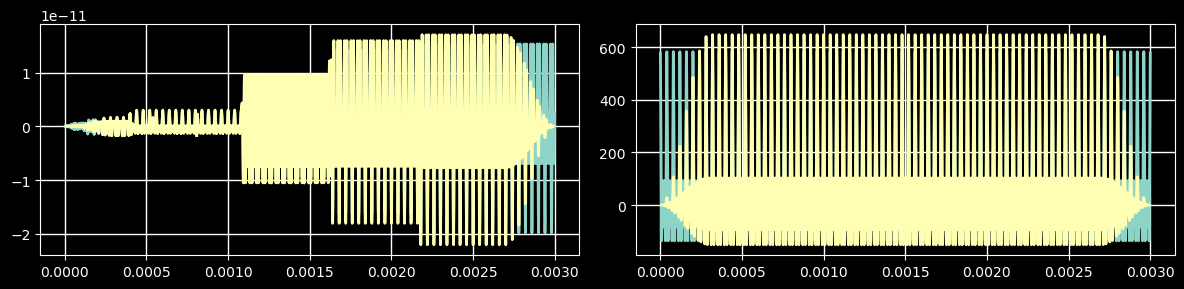

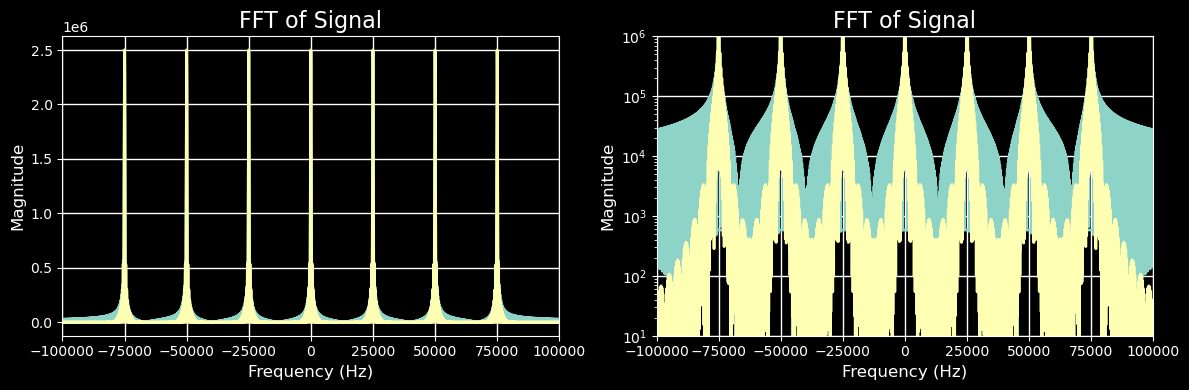

In [469]:
Tenc = 3e-3
times = np.arange(0, Tenc, 1e-7)
fq =25e3
Hstatic = (Iz**2*fq/2)
freq_array = np.arange(-3, 4) * fq
channel_signals_square = (0.25/Tenc)*np.exp(1j*(2*np.pi*freq_array*times.reshape(len(times),1) + np.pi/2))
channel_signals_shaped = (0.25/Tenc)*sin_sq_env(times, times[-1], 0.1).reshape(len(times), 1)*np.exp(1j*(2*np.pi*freq_array*times.reshape(len(times),1) + np.pi/2))

signal = np.sum(channel_signals_square, axis=1, dtype=np.complex128)
signal_shaped = np.sum(channel_signals_shaped, axis=1, dtype=np.complex128)

fig1, axs = plt.subplots(1, 2, figsize=(12, 3))
axs[0].plot(times, signal.real)
axs[0].plot(times, signal_shaped.real)
axs[1].plot(times, signal.imag)
axs[1].plot(times, signal_shaped.imag)

signal_padded = np.pad(signal, (int(1e6), int(1e6)), mode='constant')
signal_shaped_padded = np.pad(signal_shaped, (int(1e6), int(1e6)), mode='constant')
fft_signal = np.fft.fft(signal_padded)
freqs_signal = np.fft.fftfreq(len(signal_padded), times[1]-times[0])
freqs_signal, fft_signal = reorder_freqs(freqs_signal, fft_signal)

fft_signal_shaped = np.fft.fft(signal_shaped_padded)
freqs_signal_shaped = np.fft.fftfreq(len(signal_shaped_padded), times[1]-times[0])
freqs_signal_shaped, fft_signal_shaped = reorder_freqs(freqs_signal_shaped, fft_signal_shaped)

fig2, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(freqs_signal, np.abs(fft_signal))
axs[0].plot(freqs_signal_shaped, np.abs(fft_signal_shaped))
axs[0].set_xlim(-100000, 100000)
axs[0].set_xlabel('Frequency (Hz)')
axs[0].set_ylabel('Magnitude')
axs[0].set_title('FFT of Signal')
axs[1].semilogy(freqs_signal, np.abs(fft_signal))
axs[1].semilogy(freqs_signal_shaped, np.abs(fft_signal_shaped))
axs[1].set_ylim(1e1, 1e6)
axs[1].set_xlim(-100000, 100000)
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Magnitude')
axs[1].set_title('FFT of Signal')
fig1.tight_layout()
fig2.tight_layout()

plt.show()

In [470]:
def gen_rotating_frame(state, Hstatic, t):
    if isinstance(state, list):
        assert len(state) == len(t)
        state_n = []
        for i, time in enumerate(t):
            Gen = (1j * 2*np.pi * Hstatic * time).expm()
            if state[i].isket:
                state_n.append(Gen * state[i])
            else:
                state_n.append(Gen * state[i] * Gen.dag())
        return state_n
    Gen = (1j * 2*np.pi * Hstatic * t).expm()
    if state.isket:
        return Gen * state
    else: 
        return Gen * state * Gen.dag()


In [471]:
res = qt.mesolve([2*np.pi*Hstatic, [Ix, 2*np.pi*np.real(signal_shaped)], [Iy, 2*np.pi*np.imag(signal_shaped)]],  qt.basis(8, 0), times) #e_ops=[Iz, Ix, Iy])
res

<Result
  Solver: sesolve
  Solver stats:
    method: 'scipy zvode adams'
    init time: 0.002493143081665039
    preparation time: 0.0029935836791992188
    run time: 0.39279723167419434
    solver: 'Schrodinger Evolution'
  Time interval: [0.0, 0.003] (30001 steps)
  Number of e_ops: 0
  States saved.
>

In [472]:
states_lf = res.states
states_rf = gen_rotating_frame(states_lf, Hstatic, times)

In [473]:
plt.style.use('dark_background')

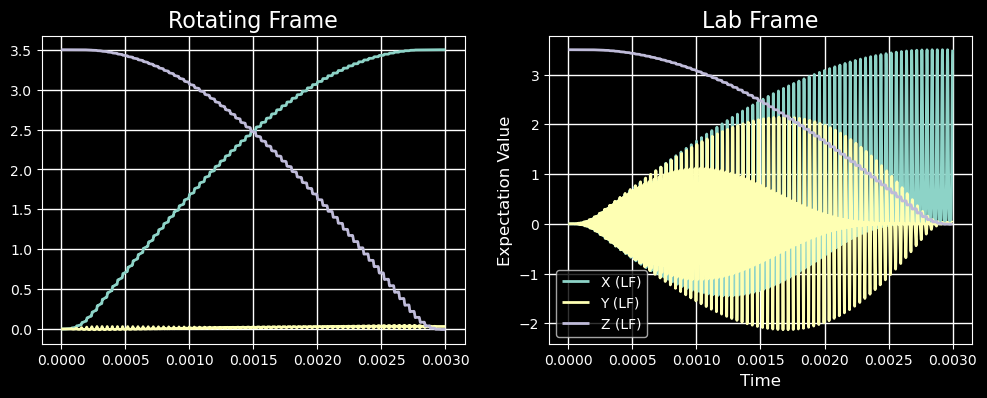

In [483]:
exp_z_rf = []
exp_y_rf = []
exp_x_rf = []
exp_z_lf = []
exp_y_lf = []
exp_x_lf = []
for i, t in enumerate(times):
    exp_z_rf.append(qt.expect(Iz, states_rf[i]))
    exp_y_rf.append(qt.expect(Iy, states_rf[i]))
    exp_x_rf.append(qt.expect(Ix, states_rf[i]))
    exp_z_lf.append(qt.expect(Iz, states_lf[i]))
    exp_y_lf.append(qt.expect(Iy, states_lf[i]))
    exp_x_lf.append(qt.expect(Ix, states_lf[i]))


fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(times, exp_x_rf, label='X (RF)')
axs[0].plot(times, exp_y_rf, label='Y (RF)')
axs[0].plot(times, exp_z_rf, label='Z (RF)')
axs[0].set_title('Rotating Frame')
axs[1].plot(times, exp_x_lf, label='X (LF)')
axs[1].plot(times, exp_y_lf, label='Y (LF)')
axs[1].set_title('Lab Frame')
plt.plot(times, exp_z_lf, label='Z (LF)')
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.show()

In [484]:
target_U = (-1j * np.pi/2 *Iy).expm()  # Target unitary operation for the simulation
target_U * qt.basis(8,0)

Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.08838835]
 [0.23385359]
 [0.40504629]
 [0.52291252]
 [0.52291252]
 [0.40504629]
 [0.23385359]
 [0.08838835]]

In [485]:
Hqevo = qt.QobjEvo([2*np.pi*Hstatic, [Ix, 2*np.pi*np.real(signal_shaped)], [Iy, 2*np.pi*np.imag(signal_shaped)]], tlist=times)
U_shaped_lf = qt.propagator(Hqevo, times)
Hqevo = qt.QobjEvo([2*np.pi*Hstatic, [Ix, 2*np.pi*np.real(signal)], [Iy, 2*np.pi*np.imag(signal)]], tlist=times)
U_square_lf = qt.propagator(Hqevo, times)

In [486]:
U_shaped = gen_rotating_frame(U_shaped_lf, Hstatic, times)
U_square = gen_rotating_frame(U_square_lf, Hstatic, times)

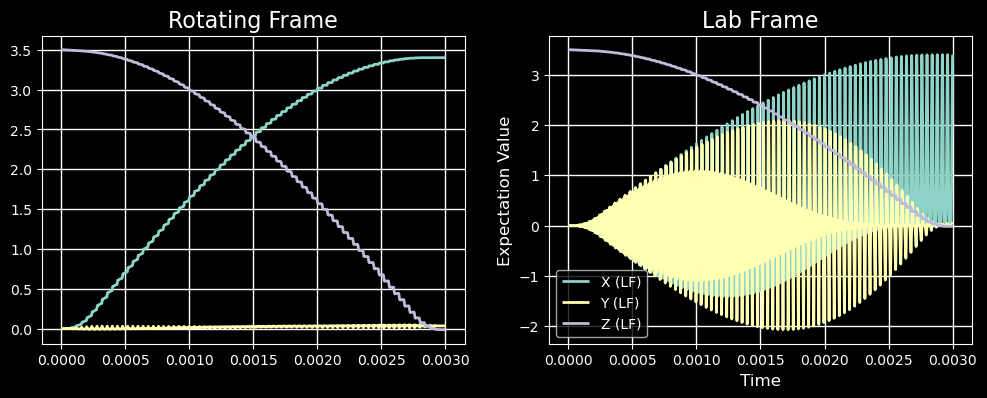

In [487]:
test_states_lf = []
for u in U_shaped_lf:
    test_state = u * qt.basis(8,0)
    test_states_lf.append(test_state)

test_states_rf = []
for u in U_shaped:
    test_state = u * qt.basis(8,0)
    test_states_rf.append(test_state)

exp_z_rf = []
exp_y_rf = []
exp_x_rf = []
exp_z_lf = []
exp_y_lf = []
exp_x_lf = []
for i, t in enumerate(times):
    exp_z_rf.append(qt.expect(Iz, test_states_rf[i]))
    exp_y_rf.append(qt.expect(Iy, test_states_rf[i]))
    exp_x_rf.append(qt.expect(Ix, test_states_rf[i]))
    exp_z_lf.append(qt.expect(Iz, test_states_lf[i]))
    exp_y_lf.append(qt.expect(Iy, test_states_lf[i]))
    exp_x_lf.append(qt.expect(Ix, test_states_lf[i]))


fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(times, exp_x_rf, label='X (RF)')
axs[0].plot(times, exp_y_rf, label='Y (RF)')
axs[0].plot(times, exp_z_rf, label='Z (RF)')
axs[0].set_title('Rotating Frame')
axs[1].plot(times, exp_x_lf, label='X (LF)')
axs[1].plot(times, exp_y_lf, label='Y (LF)')
axs[1].set_title('Lab Frame')
plt.plot(times, exp_z_lf, label='Z (LF)')
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.show()

In [488]:
s = U_shaped[-1] * (qt.basis(8,0) + -1j*qt.basis(8,7))/np.sqrt(2)
s

Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.00262658-0.08293306j]
 [-0.235303  +0.00251312j]
 [ 0.00087445-0.39291766j]
 [-0.51876876+0.00260948j]
 [-0.00260948-0.51876876j]
 [-0.39291766-0.00087445j]
 [-0.00251312-0.235303j  ]
 [-0.08293306-0.00262658j]]

In [489]:
parity_op = np.zeros((8, 8), dtype=np.complex128)
for i in range(8):
    parity_op[i, i] = (-1) ** bin(i).count('1')
parity_op = qt.Qobj(parity_op)
parity_op

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]

In [490]:
s = U_shaped[-1] * (qt.basis(8,0) - np.exp(1j*np.pi/300) * qt.basis(8,7))/np.sqrt(2)
# s*np.exp(-1j*np.angle(s.full()[0]))
qt.expect(parity_op, s)

-0.7310551218585467

In [493]:
qt.process_fidelity(target_U, U_shaped[-1])

np.float64(0.9890362638434073)

In [500]:
qt.process_fidelity(qt.propagator(Hstatic, times[-1])*target_U, U_shaped_lf[-1])

np.float64(0.3998432636305693)

In [352]:
S = (-1j*2*np.pi*times[-1]*Hstatic).expm()
lf_target_U = S.dag() * target_U * S

In [353]:
grape_result = grape.grape_unitary(lf_target_U, 2*np.pi*Hstatic, [2*np.pi*Ix, 2*np.pi*Iy, 2*np.pi*Iz, 2*np.pi*Iz**2], 100, times, u_start = [np.real(signal_shaped), np.imag(signal_shaped)])

In [512]:
np.diag((Iz**2/2).full())-0.125

array([6.+0.j, 3.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 3.+0.j, 6.+0.j])

(<Figure size 800x800 with 4 Axes>,
 array([[<Axes: xlabel='$t$', ylabel='0'>],
        [<Axes: xlabel='$t$', ylabel='1'>],
        [<Axes: xlabel='$t$', ylabel='2'>],
        [<Axes: xlabel='$t$', ylabel='3'>]], dtype=object))

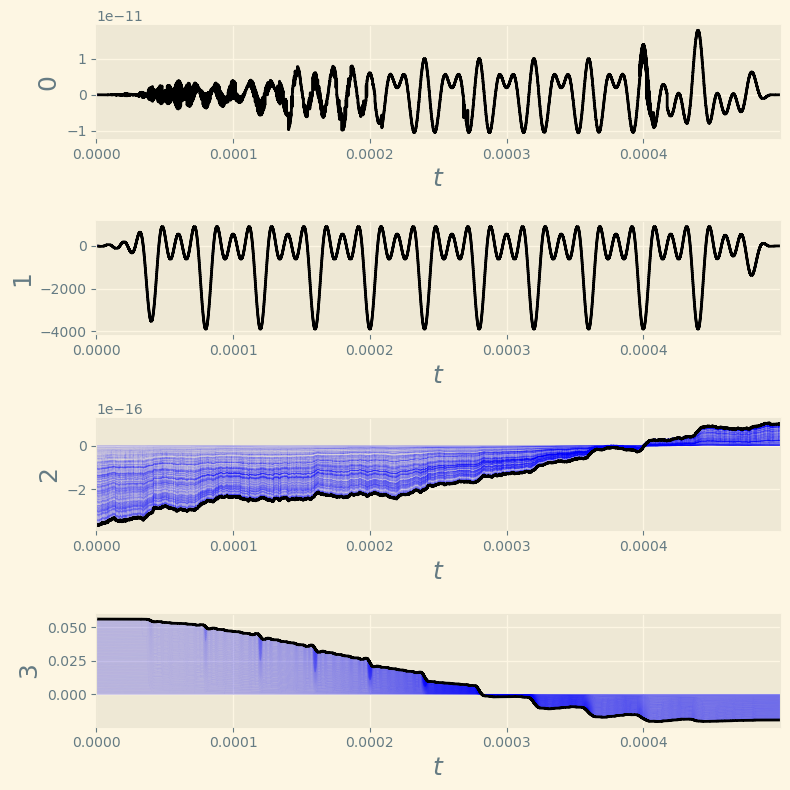

In [354]:
grape.plot_grape_control_fields(times, grape_result.u, labels=[*np.arange(7), *np.arange(7)])

In [501]:
0.05*Iz**2

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.6125 0.     0.     0.     0.     0.     0.     0.    ]
 [0.     0.3125 0.     0.     0.     0.     0.     0.    ]
 [0.     0.     0.1125 0.     0.     0.     0.     0.    ]
 [0.     0.     0.     0.0125 0.     0.     0.     0.    ]
 [0.     0.     0.     0.     0.0125 0.     0.     0.    ]
 [0.     0.     0.     0.     0.     0.1125 0.     0.    ]
 [0.     0.     0.     0.     0.     0.     0.3125 0.    ]
 [0.     0.     0.     0.     0.     0.     0.     0.6125]]

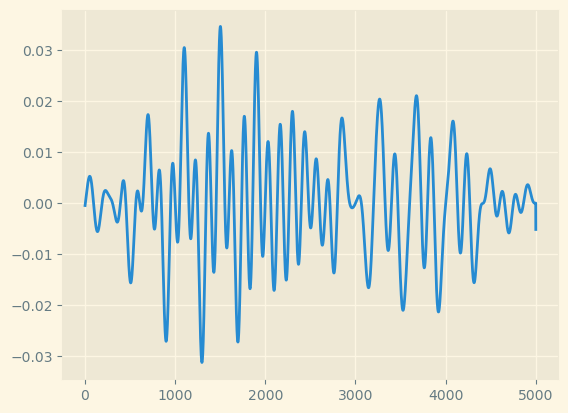

In [355]:
plt.plot(grape_result.u[0,1, :] - grape_result.u[-1,1, :])

In [357]:
qt.ket2dm(gen_rotating_frame(grape_result.U_f *qt.basis(8, 0), Hstatic, times[-1]))

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.0079552 +0.j         -0.02103313-0.00161606j  0.03620916+0.00251046j
  -0.04661994-0.00125133j  0.04649362-0.00146271j -0.03581588+0.00362748j
   0.02040673-0.00390708j -0.00752304+0.00254734j]
 [-0.02103313+0.00161606j  0.0559388 +0.j         -0.09624513+0.00071818j
   0.12351491-0.00616216j -0.1226296 +0.01331228j  0.09395843-0.01686669j
  -0.05316064+0.01447564j  0.01937306-0.00826329j]
 [ 0.03620916-0.00251046j -0.09624513-0.00071818j  0.16560313+0.j
  -0.21259186+0.00901649j  0.21116044-0.02132996j -0.16187609+0.02781356j
   0.09165103-0.02422345j -0.03343828+0.01396863j]
 [-0.04661994+0.00125133j  0.12351491+0.00616216j -0.21259186-0.00901649j
   0.27340423+0.j         -0.27223708+0.01588526j  0.20932165-0.0268919j
  -0.11897525+0.02610661j  0.0436867 -0.01611154j]
 [ 0.04649362+0.00146271j -0.1226296 -0.01331228j  0.21116044+0.02132996j
  -0.27223708-0.01588526j  0.27199788+0.j 

In [360]:
grape_result.U_f

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.08408354+0.02975156j -0.21853443+0.0815391j  -0.38390863+0.1265003j
  -0.50419982+0.13584767j -0.51145349+0.10858898j -0.40075732+0.06518941j
  -0.23401089+0.02559676j -0.0890426 +0.00121094j]
 [-0.21151847+0.10582411j -0.39814674+0.19384949j -0.42116984+0.18358221j
  -0.18257778+0.07622692j  0.19054344-0.05039282j  0.44157794-0.12104833j
   0.42771549-0.1097002j   0.22839832-0.04583246j]
 [ 0.35947125-0.19074472j  0.40552469-0.2113983j   0.0764488 -0.04073171j
  -0.31718031+0.13070421j -0.31444545+0.13501375j  0.08986594-0.01239686j
   0.43590282-0.14770623j  0.38341721-0.12607753j]
 [ 0.46825708-0.23267906j  0.17047445-0.09490103j -0.31294939+0.141259j
  -0.23772956+0.11800682j  0.2496659 -0.0916224j   0.31022561-0.14546855j
  -0.18866685+0.06688671j -0.47977717+0.20447921j]
 [-0.47977717+0.20447921j  0.18866685-0.06688671j  0.31022561-0.14546855j
  -0.2496659 +0.0916224j  -0.237729

In [361]:
lf_target_U

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.08838835-3.46944695e-18j -0.23359398+1.10160125e-02j
  -0.40379767+3.17795659e-02j  0.52059181-4.92104149e-02j
   0.52059181-4.92104149e-02j -0.40379767+3.17795659e-02j
  -0.23359398+1.10160125e-02j  0.08838835+0.00000000e+00j]
 [ 0.23359398+1.10160125e-02j -0.44194174+0.00000000e+00j
  -0.4590527 +1.44263123e-02j  0.19742295-9.31022980e-03j
  -0.19742295+9.31022980e-03j  0.4590527 -1.44263123e-02j
   0.44194174+0.00000000e+00j -0.23359398-1.10160125e-02j]
 [-0.40379767-3.17795659e-02j  0.4590527 +1.44263123e-02j
   0.08838835+0.00000000e+00j  0.34228437-5.37703251e-03j
   0.34228437-5.37703251e-03j  0.08838835-3.46944695e-18j
   0.4590527 +1.44263123e-02j -0.40379767-3.17795659e-02j]
 [-0.52059181-4.92104149e-02j  0.19742295+9.31022980e-03j
  -0.34228437-5.37703251e-03j  0.26516504-1.38777878e-17j
  -0.26516504+0.00000000e+00j  0.34228437+5.37703251e-03j
  -0.19742295-9.31022980e-03j

In [363]:
qt.process_fidelity(lf_target_U, grape_result.U_f)

np.float64(0.00027331212403205237)

In [364]:
opt_process_fidelity(lf_target_U, grape_result.U_f)

(np.float64(0.8658860705518642),
 array([ 0.67255739, -0.80088414, -0.73757843,  0.86590649,  0.86590652,
        -0.73757844, -0.80088405,  0.67255741]))

# Ix^2 drive

In [722]:
init_state = (1j*np.pi/2*Iy).expm() * (qt.basis(8,0) + 1j*qt.basis(8,7))/np.sqrt(2)

In [ ]:
time_array = np.linspace(0, 100e-3, 31)

pulses = 

In [7]:
HNER = (spin_op['Ip']/2)**2 + (spin_op['Im']/2)**2  # Define the Hamiltonian for the NER drive

In [780]:
fq = 25e3
fq2 = 0
fz = 7.7e6
nmr_freqs = fz + fq*np.arange(-3, 4) + fq2*np.arange(-3, 4)**2/1
drive_dict={
        'nmr': {
        'frequencies': nmr_freqs,
        'operator': qt.jmat(7/2, 'x'),
        'order': 1
        },
        'ner2': {
            'frequencies': nmr_freqs[1:] + nmr_freqs[:-1],
            'operator': HNER,
            'order': 2
        }
    }

In [796]:
HNER - Iz**2/2 + 7.875

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1.75       0.         2.29128785 0.         0.         0.
  0.         0.        ]
 [0.         4.75       0.         3.35410197 0.         0.
  0.         0.        ]
 [2.29128785 0.         6.75       0.         3.87298335 0.
  0.         0.        ]
 [0.         3.35410197 0.         7.75       0.         3.87298335
  0.         0.        ]
 [0.         0.         3.87298335 0.         7.75       0.
  3.35410197 0.        ]
 [0.         0.         0.         3.87298335 0.         6.75
  0.         2.29128785]
 [0.         0.         0.         0.         3.35410197 0.
  4.75       0.        ]
 [0.         0.         0.         0.         0.         2.29128785
  0.         1.75      ]]

In [12]:
np.diff(np.real(np.diag((Iz**2/2).full())))

array([-3., -2., -1.,  0.,  1.,  2.,  3.])

In [10]:
Ix**2

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1.75       0.         2.29128785 0.         0.         0.
  0.         0.        ]
 [0.         4.75       0.         3.35410197 0.         0.
  0.         0.        ]
 [2.29128785 0.         6.75       0.         3.87298335 0.
  0.         0.        ]
 [0.         3.35410197 0.         7.75       0.         3.87298335
  0.         0.        ]
 [0.         0.         3.87298335 0.         7.75       0.
  3.35410197 0.        ]
 [0.         0.         0.         3.87298335 0.         6.75
  0.         2.29128785]
 [0.         0.         0.         0.         3.35410197 0.
  4.75       0.        ]
 [0.         0.         0.         0.         0.         2.29128785
  0.         1.75      ]]

In [8]:
HNER

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.         0.         2.29128785 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         3.35410197 0.         0.
  0.         0.        ]
 [2.29128785 0.         0.         0.         3.87298335 0.
  0.         0.        ]
 [0.         3.35410197 0.         0.         0.         3.87298335
  0.         0.        ]
 [0.         0.         3.87298335 0.         0.         0.
  3.35410197 0.        ]
 [0.         0.         0.         3.87298335 0.         0.
  0.         2.29128785]
 [0.         0.         0.         0.         3.35410197 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         2.29128785
  0.         0.        ]]

In [984]:
3e-3

0.003

c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


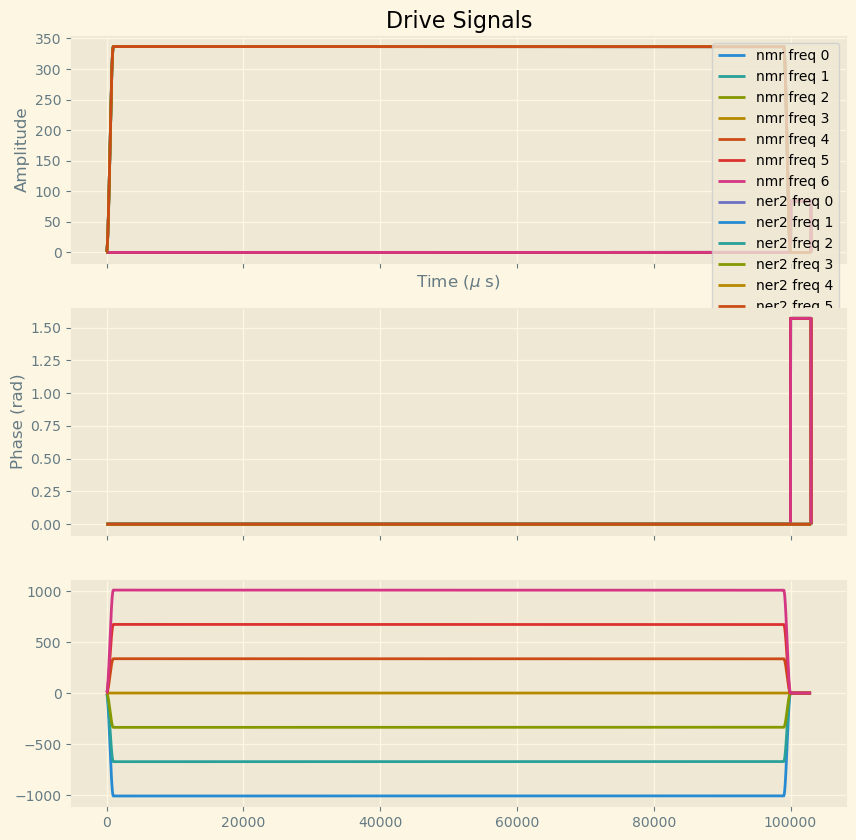

In [ ]:
pulses = DriveSignal(
    drive_dict,
    pulse_shapes=pulse_shape_dict,
    dt=1e-7
)

amp = 1/3e-3
amp2 = 1/12e-3
pulses.init_drive_signal_list()
# pulses.frame_rotation('ner2', np.pi)
# shift = np.array([ 0.05555556, -5.32638889, -2.83333333,  0.        ,  2.83333333, 5.32638889, -0.05555556])
shift = np.array([ 0.06722222, -6.44493056, -3.42833333,  0.        ,  3.42833333, 6.44493056, -0.06722222])
# pulses.set_selfconsistent_detuning(shift)
pulses.pulse_shapes['sin_sq']['args']['Trise'] = 0.01
pulses.set_selfconsistent_detuning(shift)
pulses.global_pulse('ner2', T=100e-3, amp=amp, pulse_shape='sin_sq', freq_mod_signal=np.arange(-3, 4))
pulses.align()
pulses.set_selfconsistent_detuning(np.zeros(7))
pulses.frame_rotation('nmr', -np.pi/2)
pulses.global_pulse('nmr', T=0.25/amp2, amp=-amp2, pulse_shape='sin_sq')
pulses.finish_pulse_sequence()
pulses.plot_signal()

H, time_array = pulses.get_drive_hamiltonian(nmr_freqs, cross_coupling_cutoff_frequency=None, cross_coupling_only=False)

In [1013]:
res = qt.mesolve(H, init_state, time_array)

In [1014]:
pop_list = []
I_exp_vals = []
for s in res.states:
    dm = qt.ket2dm(s)
    pops = np.real(np.diag(dm.full()))  
    pop_list.append(pops)
    I_exp_vals.append([qt.expect(spin_op['Ix'], dm), qt.expect(spin_op['Iy'], dm), qt.expect(spin_op['Iz'], dm)])

c:\Users\z5459883\AppData\Local\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


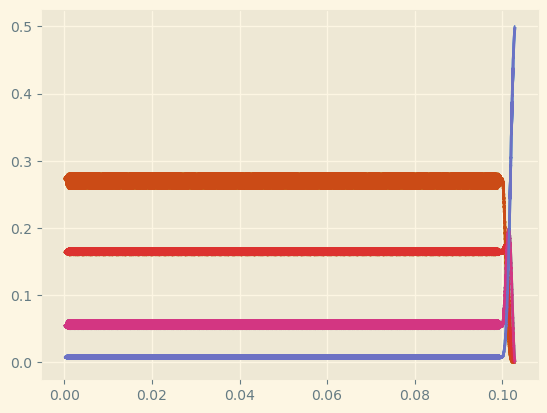

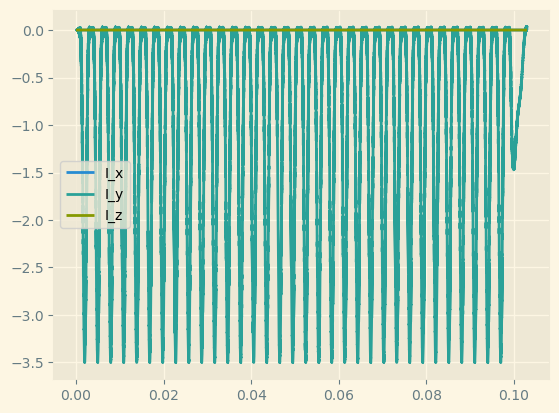

In [1015]:
pop_arr = np.array(pop_list)
Iexp_arr = np.array(I_exp_vals)
plt.plot(time_array, pop_arr)
plt.figure()
plt.plot(time_array, Iexp_arr)
plt.legend(['I_x', 'I_y', 'I_z'])

In [1017]:
qt.ket2dm(res.states[-1])

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 4.99890438e-01+0.00000000e+00j  2.52237417e-03-6.37559796e-03j
   7.02808342e-06+2.65533816e-03j -8.38364761e-04-6.87551207e-05j
   6.87551207e-05-8.38364761e-04j  2.65533816e-03-7.02808340e-06j
   6.37559796e-03+2.52237417e-03j -1.57651669e-14-4.99890438e-01j]
 [ 2.52237417e-03+6.37559796e-03j  9.40418484e-05+0.00000000e+00j
  -3.38306954e-05+1.34880849e-05j -3.35336403e-06-1.10394246e-05j
   1.10394246e-05-3.35336403e-06j  1.34880849e-05+3.38306954e-05j
   2.12883097e-16+9.40418484e-05j  6.37559796e-03-2.52237417e-03j]
 [ 7.02808342e-06-2.65533816e-03j -3.38306954e-05-1.34880849e-05j
   1.41048310e-05+0.00000000e+00j -3.77002997e-07+4.45229306e-06j
  -4.45229306e-06-3.77002997e-07j  6.13522904e-17-1.41048310e-05j
   1.34880849e-05-3.38306954e-05j -2.65533816e-03-7.02808342e-06j]
 [-8.38364761e-04+6.87551207e-05j -3.35336403e-06+1.10394246e-05j
  -3.77002997e-07-4.45229306e-06j  1.41547

In [872]:
res.states[100]

Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
Qobj data =
[[0.01225953-0.08668895j]
 [0.16584824+0.16351386j]
 [0.37785575-0.14538552j]
 [0.08069331+0.51736736j]
 [0.51736736-0.08069331j]
 [0.14538552+0.37785575j]
 [0.16351386-0.16584824j]
 [0.08668895+0.01225953j]]

In [922]:
states = []
for t in time_array:
    # state = (-1j*0*Iz).expm()*(-1j*t*2*np.pi*amp*(HNER-Iz**2/2) ).expm() * (1j*0*Iz).expm()*init_state
    state = (-1j*t*2*np.pi*amp/2*Iz**2).expm()*init_state
    states.append(state)

In [923]:

pop_list = []
I_exp_vals = []
for s in states:
    dm = qt.ket2dm(s)
    pops = np.real(np.diag(dm.full()))  
    pop_list.append(pops)
    I_exp_vals.append([qt.expect(spin_op['Ix'], dm), qt.expect(spin_op['Iy'], dm), qt.expect(spin_op['Iz'], dm)])

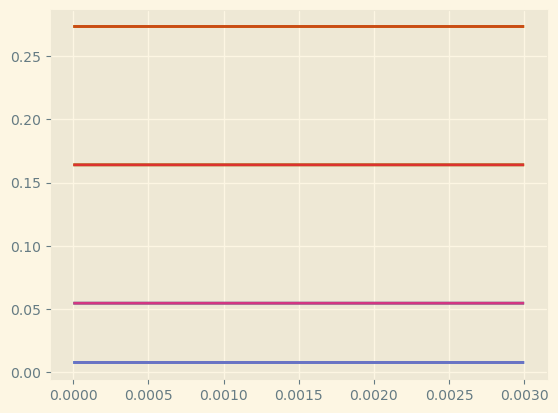

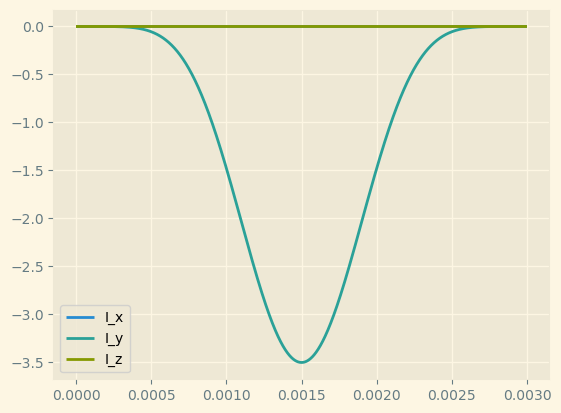

In [924]:
pop_arr = np.array(pop_list)
Iexp_arr = np.array(I_exp_vals)
plt.plot(time_array, pop_arr)
plt.figure()
plt.plot(time_array, Iexp_arr)
plt.legend(['I_x', 'I_y', 'I_z'])